# task3：Version11 Train-Only Aux-Head 光电混合 D2NN

这版 notebook 在 Version10 的基础上继续往前走，但核心边界更清楚：

- **学生主推理路径不改**
- **部署阶段不用新增电侧辅助头**
- **训练/蒸馏阶段允许使用更强的 electrical auxiliary interface**

Version11 的关键判断来自 Version10 的可视化：老师 grouped target 的 4 张图明显不同，
但学生用 `1x1 conv(1 -> K)` 得到的 4 张 grouped prediction 很容易塌缩成“同一张图的不同缩放版”。

因此，这版的核心变化是：

1. 老师仍然输出 grouped target
2. 学生主 backbone 仍然只输出原来的单张 `pooled_map`
3. 但训练阶段新增 **small CNN auxiliary grouped head**
4. 这个 auxiliary head 只用于蒸馏，不用于最终部署推理

一句话概括：

**Version11 = richer teacher target + stronger training-only distillation interface + unchanged inference path**


## 0) 导入依赖 + 全局基础配置

这版继续保持你比较满意的 Version8 fullyrun / Version10 风格：

- 参数尽量集中到前面，便于一次性扫配置
- markdown、配置 cell、执行 cell 分清楚
- 工具函数集中，阶段执行尽量简洁
- 中文注释写清楚，避免后面回看时忘记设计边界
- 每个关键 code cell 都保留 `ok` 提示，方便 `run all` 排错

Version11 与 Version10 的边界差异请记住：

- Version10：grouped target + 极轻 `1x1 projector`
- Version11：grouped target + **training-only small CNN aux head**

这里的 aux head 只负责“蒸馏接口补能力”，不是部署主链路的一部分。


In [3]:
import os
import json
import math
import time
import random
from copy import deepcopy
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import functional as TF
from torchvision.models import vit_b_16, ViT_B_16_Weights

from tqdm.auto import tqdm


plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

SEED = 42
NUM_CLASSES = 10
CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

DATA_DIR = Path("./data")
OUT_DIR = Path("./results_task3_kd_v11_auxhead")
CKPT_DIR = OUT_DIR / "checkpoints"
LOG_DIR = OUT_DIR / "logs"
FIG_DIR = OUT_DIR / "figures"
for p in [OUT_DIR, CKPT_DIR, LOG_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)
print("OUT_DIR =", OUT_DIR.resolve())

GRAY_D2NN_BASELINE_REF_ACC = 0.57
GRAY_V8_STRONG_KD_REF_ACC = 0.6616
GRAY_V10_SHORT_REF_ACC = 0.65

STUDENT_IMG_SIZE = 128
TEACHER_IMG_SIZE = 224
BATCH_SIZE = 64
NUM_WORKERS = 2
ALIGN_POOL_SIZE = 14

D2NN_NUM_LAYERS = 12
D2NN_CHANNELS = 1
D2NN_WAVELENGTH = 532e-9
D2NN_PIXEL_SIZE = 8e-6
D2NN_PROP_DISTANCE = 0.01

INPUT_EPS = 1e-8
CMOS_EPS = 1e-8

V11_GROUP_COUNT = 4
V11_GROUPING_MODE = "interleave"
V11_GROUP_TARGET_MODE = "group_rms"
V11_AUX_GROUP_HEAD_POSITIVE_MODE = "softplus"
V11_AUX_GROUP_HEAD_HIDDEN = 16
V11_AUX_GROUP_HEAD_USE_BATCHNORM = False

AUTO_PLOT_HISTORY = True
AUTO_VISUALIZE_TARGETS = True
AUTO_SAVE_PLOTS = True
VIS_NUM_SAMPLES = 2
VIS_LAYERS = (1, 6, 12)
VIS_GROUPS = tuple(range(V11_GROUP_COUNT))


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")


def format_seconds(seconds: float) -> str:
    seconds = max(float(seconds), 0.0)
    h = int(seconds // 3600)
    m = int((seconds % 3600) // 60)
    s = int(seconds % 60)
    if h > 0:
        return f"{h:d}h {m:02d}m {s:02d}s"
    return f"{m:02d}m {s:02d}s"


def set_trainable(module: nn.Module, flag: bool):
    if module is None:
        return
    for p in module.parameters():
        p.requires_grad = flag


def count_trainable_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


def flexible_load_state_dict(model: nn.Module, ckpt_path: Path, strict: bool = False):
    payload = torch.load(ckpt_path, map_location="cpu")
    if isinstance(payload, dict):
        state = payload.get("model_state_dict", payload.get("state_dict", payload))
    else:
        state = payload
    missing, unexpected = model.load_state_dict(state, strict=strict)
    print(f"已加载 checkpoint: {ckpt_path}")
    if len(missing) > 0:
        print("missing keys 数量 =", len(missing))
    if len(unexpected) > 0:
        print("unexpected keys 数量 =", len(unexpected))
    return payload


set_seed(SEED)
print("ok: 0) 导入依赖 + 全局基础配置")


DEVICE = cuda
OUT_DIR = /D2NN_practices/results_task3_kd_v11_auxhead
ok: 0) 导入依赖 + 全局基础配置


## 1) 灰度 CIFAR-10 双视角数据

这里继续沿用你已经跑顺的双视角设置：

- `x_student` 给 D2NN 学生，单通道灰度，尺寸 `128`
- `x_teacher` 给 ViT 老师，灰度复制成三通道，再按 ImageNet 方式归一化，尺寸 `224`

这样做的好处是：

- 学生保持光学输入逻辑不变
- 老师仍然能直接复用 ViT 的成熟实现
- 以后要换别的任务，只需要尽量在这一层替换数据模块


train size = 50000 | test size = 10000
train batches = 782 | test batches = 157
gray baseline reference = 57.00%
v8 strong kd reference = 66.16%


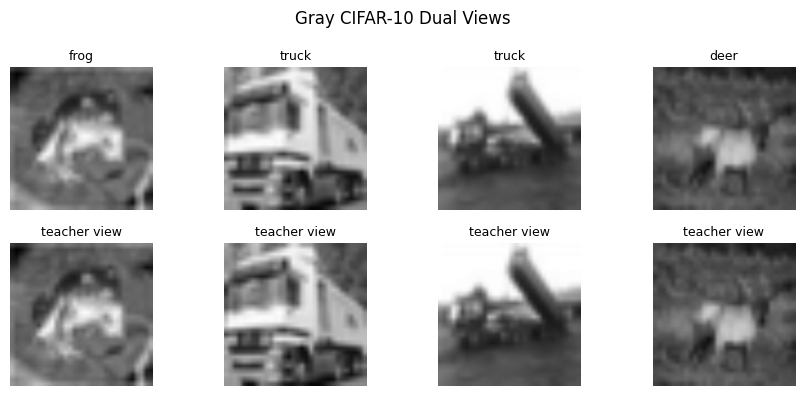

ok: 1) 灰度 CIFAR-10 双视角数据


In [8]:
class CIFAR10GrayDualView(Dataset):
    def __init__(self, root, train: bool = True, download: bool = True, student_img_size: int = STUDENT_IMG_SIZE, teacher_img_size: int = TEACHER_IMG_SIZE):
        self.base = datasets.CIFAR10(root=root, train=train, download=download, transform=None)
        self.train = train
        self.student_img_size = student_img_size
        self.teacher_img_size = teacher_img_size
        self.teacher_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.teacher_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.base)

    def _to_gray_tensor(self, pil_img, size: int):
        img = TF.resize(pil_img, [size, size])
        img = TF.to_grayscale(img, num_output_channels=1)
        x = TF.to_tensor(img)
        return x

    def _to_teacher_tensor(self, pil_img, size: int):
        gray = self._to_gray_tensor(pil_img, size)
        rgb = gray.repeat(3, 1, 1)
        rgb = (rgb - self.teacher_mean) / self.teacher_std
        return rgb

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.train and random.random() < 0.5:
            img = TF.hflip(img)
        x_student = self._to_gray_tensor(img, self.student_img_size)
        x_teacher = self._to_teacher_tensor(img, self.teacher_img_size)
        return x_student, x_teacher, label


train_ds = CIFAR10GrayDualView(root=DATA_DIR, train=True, download=True, student_img_size=STUDENT_IMG_SIZE, teacher_img_size=TEACHER_IMG_SIZE)
test_ds = CIFAR10GrayDualView(root=DATA_DIR, train=False, download=True, student_img_size=STUDENT_IMG_SIZE, teacher_img_size=TEACHER_IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


def show_gray_dual_samples(dataset, classes, n: int = 6):
    n = min(n, len(dataset))
    plt.figure(figsize=(2.2 * n, 4.0))
    for i in range(n):
        x_student, x_teacher, y = dataset[i]
        plt.subplot(2, n, i + 1)
        plt.imshow(x_student.squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        plt.title(classes[y], fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        teacher_vis = x_teacher.permute(1, 2, 0).cpu()
        teacher_vis = teacher_vis * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        teacher_vis = teacher_vis.clamp(0, 1)
        plt.imshow(teacher_vis)
        plt.title("teacher view", fontsize=9)
        plt.axis("off")
    plt.suptitle("Gray CIFAR-10 Dual Views")
    plt.tight_layout()
    plt.show()


print("train size =", len(train_ds), "| test size =", len(test_ds))
print("train batches =", len(train_loader), "| test batches =", len(test_loader))
print("gray baseline reference =", f"{GRAY_D2NN_BASELINE_REF_ACC * 100:.2f}%")
print("v8 strong kd reference =", f"{GRAY_V8_STRONG_KD_REF_ACC * 100:.2f}%")
show_gray_dual_samples(train_ds, CLASSES, n=4)
print("ok: 1) 灰度 CIFAR-10 双视角数据")


## 2) ViT 老师模型 + teacher target builder

Version11 的核心不是换老师主干，而是升级老师给学生的 target。

当前仍然默认使用 `ViT-B/16`，但把 target builder 明确拆出来，方便未来：

- 继续保留单张 `patch_rms map`
- 新增 `grouped maps target`

这一步的要点是：

- 老师本体不变
- 老师 hidden 的压缩方式升级
- 让学生仍然学非负空间图，但信息量比单张 map 更丰富


In [9]:
class GrayViTTeacherV11(nn.Module):
    expects_teacher_input = True

    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True, arch_name: str = "vit_b16"):
        super().__init__()
        self.arch_name = arch_name
        if arch_name != "vit_b16":
            raise ValueError(f"当前 notebook 先稳定支持 vit_b16，收到 arch_name={arch_name}")

        weights = ViT_B_16_Weights.DEFAULT if pretrained else None
        self.backbone = vit_b_16(weights=weights)
        hidden_dim = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_classes),
        )
        self.hidden_dim = hidden_dim
        self.num_blocks = len(self.backbone.encoder.layers)

    def forward(self, x_teacher: torch.Tensor) -> torch.Tensor:
        return self.backbone(x_teacher)

    def forward_with_patch_tokens(self, x_teacher: torch.Tensor):
        patch_tokens = self.backbone._process_input(x_teacher)
        n = patch_tokens.shape[0]
        cls = self.backbone.class_token.expand(n, -1, -1)
        tokens = torch.cat([cls, patch_tokens], dim=1)
        tokens = tokens + self.backbone.encoder.pos_embedding
        tokens = self.backbone.encoder.dropout(tokens)

        block_patch_tokens = []
        block_cls_tokens = []
        for block in self.backbone.encoder.layers:
            tokens = block(tokens)
            block_cls_tokens.append(tokens[:, 0, :])
            block_patch_tokens.append(tokens[:, 1:, :])

        tokens = self.backbone.encoder.ln(tokens)
        logits = self.backbone.heads(tokens[:, 0])
        return {
            "logits": logits,
            "block_patch_tokens": block_patch_tokens,
            "block_cls_tokens": block_cls_tokens,
        }


def compress_patch_tokens_to_map(patch_tokens: torch.Tensor, mode: str = "patch_rms", eps: float = 1e-8):
    b, n, c = patch_tokens.shape
    side = int(round(math.sqrt(n)))
    if side * side != n:
        raise ValueError(f"patch token 数量 {n} 不能还原成方阵")

    if mode == "patch_rms":
        patch_scalar = torch.sqrt(patch_tokens.pow(2).mean(dim=-1) + eps)
    elif mode == "patch_energy":
        patch_scalar = patch_tokens.pow(2).mean(dim=-1)
        patch_scalar = patch_scalar / (patch_scalar.sum(dim=-1, keepdim=True) + eps)
    elif mode == "patch_abs_mean":
        patch_scalar = patch_tokens.abs().mean(dim=-1)
    else:
        raise ValueError(f"Unsupported patch compression mode: {mode}")

    return patch_scalar.view(b, 1, side, side)


def compress_patch_tokens_to_grouped_maps(patch_tokens: torch.Tensor, num_groups: int = V11_GROUP_COUNT, grouping_mode: str = V11_GROUPING_MODE, mode: str = V11_GROUP_TARGET_MODE, eps: float = 1e-8):
    b, n, c = patch_tokens.shape
    side = int(round(math.sqrt(n)))
    if side * side != n:
        raise ValueError(f"patch token 数量 {n} 不能还原成方阵")
    if num_groups <= 0:
        raise ValueError("num_groups 必须大于 0")

    grouped_maps = []
    if grouping_mode == "interleave":
        channel_groups = [patch_tokens[:, :, g::num_groups] for g in range(num_groups)]
    elif grouping_mode == "contiguous":
        splits = torch.tensor_split(torch.arange(c), num_groups)
        channel_groups = [patch_tokens[:, :, idxs.tolist()] for idxs in splits]
    else:
        raise ValueError(f"Unsupported grouping_mode: {grouping_mode}")

    for group_tokens in channel_groups:
        if group_tokens.shape[-1] == 0:
            continue
        if mode == "group_rms":
            group_scalar = torch.sqrt(group_tokens.pow(2).mean(dim=-1) + eps)
        elif mode == "group_abs_mean":
            group_scalar = group_tokens.abs().mean(dim=-1)
        elif mode == "group_energy":
            group_scalar = group_tokens.pow(2).mean(dim=-1)
            group_scalar = group_scalar / (group_scalar.sum(dim=-1, keepdim=True) + eps)
        else:
            raise ValueError(f"Unsupported group target mode: {mode}")
        grouped_maps.append(group_scalar.view(b, 1, side, side))

    grouped_maps = torch.cat(grouped_maps, dim=1)
    return grouped_maps


print("ok: 2) ViT 老师模型 + teacher target builder")


ok: 2) ViT 老师模型 + teacher target builder


## 3) Student Optical Backbone + 训练期 auxiliary grouped head

这部分是 Version11 的核心改动。

不变的部分：
- 光学 backbone 本体不改
- 最终分类 head 不改
- 推理时仍然只走原来的 `final_map -> classifier`

新增的部分：
- `AuxGroupedHeadV11`
- 输入每层 `pooled_map`
- 输出该层 grouped prediction
- 只服务于训练时的 grouped KD

也就是说，这个模块不是为了让部署更强，而是为了让蒸馏接口更有表达力。


In [10]:
def apply_electrical_signal_mode(intensity: torch.Tensor, mode: str = "sqrt", eps: float = CMOS_EPS):
    if mode == "raw":
        return intensity
    if mode == "sqrt":
        return torch.sqrt(intensity + eps)
    raise ValueError(f"Unsupported electrical signal mode: {mode}")


class DiffractivePhaseLayer(nn.Module):
    def __init__(self, channels: int, height: int, width: int):
        super().__init__()
        self.raw_phase = nn.Parameter(torch.zeros(channels, height, width))

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        phase = 2 * torch.pi * torch.sigmoid(self.raw_phase)
        return field * torch.exp(1j * phase)


class AngularSpectrumPropagation(nn.Module):
    def __init__(self, img_size: int, wavelength: float, pixel_size: float, distance: float):
        super().__init__()
        fx = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fy = np.fft.fftshift(np.fft.fftfreq(img_size, d=pixel_size))
        fxx, fyy = np.meshgrid(fx, fy)
        inside = (1.0 / wavelength) ** 2 - fxx ** 2 - fyy ** 2
        inside = np.maximum(inside, 0.0)
        kz = 2 * np.pi * np.sqrt(inside)
        h = np.exp(1j * kz * distance).astype(np.complex64)
        self.register_buffer("transfer", torch.from_numpy(h), persistent=False)

    def forward(self, field: torch.Tensor) -> torch.Tensor:
        spec = torch.fft.fftshift(torch.fft.fft2(field), dim=(-2, -1))
        out_spec = spec * self.transfer
        return torch.fft.ifft2(torch.fft.ifftshift(out_spec, dim=(-2, -1)))


class CMOSReadoutV11(nn.Module):
    def __init__(self, eps: float = CMOS_EPS, electrical_mode: str = "sqrt", reconstruction_phase_mode: str = "zero", random_phase_scheme: str = "uniform_0_2pi"):
        super().__init__()
        self.eps = eps
        self.electrical_mode = electrical_mode
        self.reconstruction_phase_mode = reconstruction_phase_mode
        self.random_phase_scheme = random_phase_scheme

    def _build_reconstruction_phase(self, field: torch.Tensor) -> torch.Tensor:
        if self.reconstruction_phase_mode == "zero":
            return torch.zeros_like(field.real)
        if self.reconstruction_phase_mode == "preserve":
            return torch.angle(field)
        if self.reconstruction_phase_mode == "random":
            if self.random_phase_scheme == "uniform_0_2pi":
                return 2 * torch.pi * torch.rand_like(field.real)
            raise ValueError(f"Unsupported random_phase_scheme: {self.random_phase_scheme}")
        raise ValueError(f"Unsupported reconstruction_phase_mode: {self.reconstruction_phase_mode}")

    def forward(self, field: torch.Tensor):
        intensity = field.abs().pow(2)
        driver_map = apply_electrical_signal_mode(intensity, mode=self.electrical_mode, eps=self.eps)
        reconstruction_phase = self._build_reconstruction_phase(field)
        magnitude = driver_map.clamp_min(self.eps)
        reconstructed_field = torch.polar(magnitude, reconstruction_phase)
        return {
            "intensity": intensity,
            "driver_map": driver_map,
            "reconstruction_phase": reconstruction_phase,
            "reconstructed_field": reconstructed_field,
        }


class OpticalHybridBackboneV11(nn.Module):
    def __init__(self, img_size: int = STUDENT_IMG_SIZE, channels: int = D2NN_CHANNELS, num_layers: int = D2NN_NUM_LAYERS, wavelength: float = D2NN_WAVELENGTH, pixel_size: float = D2NN_PIXEL_SIZE, distance: float = D2NN_PROP_DISTANCE, align_pool_size: int = ALIGN_POOL_SIZE, input_field_mode: str = "sqrt", cmos_electrical_mode: str = "sqrt", cmos_reconstruction_phase_mode: str = "zero", cmos_random_phase_scheme: str = "uniform_0_2pi"):
        super().__init__()
        self.num_layers = num_layers
        self.input_field_mode = input_field_mode
        self.phase_layers = nn.ModuleList([DiffractivePhaseLayer(channels, img_size, img_size) for _ in range(num_layers)])
        self.cmos_layers = nn.ModuleList([
            CMOSReadoutV11(
                eps=CMOS_EPS,
                electrical_mode=cmos_electrical_mode,
                reconstruction_phase_mode=cmos_reconstruction_phase_mode,
                random_phase_scheme=cmos_random_phase_scheme,
            )
            for _ in range(num_layers)
        ])
        self.propagation = AngularSpectrumPropagation(img_size=img_size, wavelength=wavelength, pixel_size=pixel_size, distance=distance)
        self.align_pool = nn.AdaptiveAvgPool2d((align_pool_size, align_pool_size))

    def image_to_field(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clamp(0.0, 1.0)
        if self.input_field_mode == "sqrt":
            amp = torch.sqrt(x + INPUT_EPS)
        elif self.input_field_mode == "raw":
            amp = x
        else:
            raise ValueError(f"Unsupported input_field_mode: {self.input_field_mode}")
        return amp.to(torch.complex64)

    def forward(self, x: torch.Tensor, return_records: bool = True):
        field = self.image_to_field(x)
        records = []
        for layer_idx in range(self.num_layers):
            field = self.phase_layers[layer_idx](field)
            field = self.propagation(field)
            cmos_out = self.cmos_layers[layer_idx](field)
            pooled_map = self.align_pool(cmos_out["driver_map"])
            records.append({
                "layer_idx": layer_idx + 1,
                "intensity": cmos_out["intensity"],
                "driver_map": cmos_out["driver_map"],
                "pooled_map": pooled_map,
            })
            field = cmos_out["reconstructed_field"]
        final_map = records[-1]["driver_map"]
        if return_records:
            return final_map, records
        return final_map


class LightCNNReadoutHeadV11(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = NUM_CLASSES, dropout: float = 0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.net(x))


class AuxGroupedHeadV11(nn.Module):
    """训练期辅助 grouped head。

    设计原则：
    1. 只吃单层 pooled_map
    2. 用一个很小的 CNN 提供空间建模能力
    3. 只服务于 grouped KD，不参与部署主推理路径
    """

    def __init__(self, in_channels: int = 1, hidden_channels: int = V11_AUX_GROUP_HEAD_HIDDEN, out_channels: int = V11_GROUP_COUNT, positive_mode: str = V11_AUX_GROUP_HEAD_POSITIVE_MODE, use_batchnorm: bool = V11_AUX_GROUP_HEAD_USE_BATCHNORM):
        super().__init__()
        layers = [nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=not use_batchnorm)]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(hidden_channels))
        layers.append(nn.GELU())
        layers.append(nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1, bias=not use_batchnorm))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(hidden_channels))
        layers.append(nn.GELU())
        layers.append(nn.Conv2d(hidden_channels, out_channels, kernel_size=1, bias=True))
        self.net = nn.Sequential(*layers)
        self.positive_mode = positive_mode

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.net(x)
        if self.positive_mode == "softplus":
            return F.softplus(x)
        if self.positive_mode == "relu":
            return F.relu(x)
        if self.positive_mode == "identity":
            return x
        raise ValueError(f"Unsupported positive_mode: {self.positive_mode}")


class OpticalHybridClassifierV11(nn.Module):
    expects_teacher_input = False

    def __init__(self, backbone: OpticalHybridBackboneV11, head: LightCNNReadoutHeadV11, aux_grouped_head: AuxGroupedHeadV11):
        super().__init__()
        self.backbone = backbone
        self.head = head
        self.aux_grouped_head = aux_grouped_head

    def forward(self, x_student: torch.Tensor) -> torch.Tensor:
        final_map = self.backbone(x_student, return_records=False)
        return self.head(final_map)

    def build_grouped_predictions(self, records):
        return [self.aux_grouped_head(record["pooled_map"]) for record in records]

    def forward_with_records(self, x_student: torch.Tensor, return_grouped: bool = True):
        final_map, records = self.backbone(x_student, return_records=True)
        logits = self.head(final_map)
        if return_grouped:
            grouped_predictions = self.build_grouped_predictions(records)
            return logits, records, grouped_predictions
        return logits, records


def build_student_model_v11(cmos_electrical_mode: str = "sqrt", cmos_reconstruction_phase_mode: str = "zero", cmos_random_phase_scheme: str = "uniform_0_2pi", input_field_mode: str = "sqrt", head_dropout: float = 0.10, group_count: int = V11_GROUP_COUNT, aux_head_positive_mode: str = V11_AUX_GROUP_HEAD_POSITIVE_MODE, aux_head_hidden: int = V11_AUX_GROUP_HEAD_HIDDEN, aux_head_use_batchnorm: bool = V11_AUX_GROUP_HEAD_USE_BATCHNORM):
    backbone = OpticalHybridBackboneV11(
        img_size=STUDENT_IMG_SIZE,
        channels=D2NN_CHANNELS,
        num_layers=D2NN_NUM_LAYERS,
        input_field_mode=input_field_mode,
        cmos_electrical_mode=cmos_electrical_mode,
        cmos_reconstruction_phase_mode=cmos_reconstruction_phase_mode,
        cmos_random_phase_scheme=cmos_random_phase_scheme,
    ).to(DEVICE)
    head = LightCNNReadoutHeadV11(in_channels=D2NN_CHANNELS, num_classes=NUM_CLASSES, dropout=head_dropout).to(DEVICE)
    aux_grouped_head = AuxGroupedHeadV11(
        in_channels=1,
        hidden_channels=aux_head_hidden,
        out_channels=group_count,
        positive_mode=aux_head_positive_mode,
        use_batchnorm=aux_head_use_batchnorm,
    ).to(DEVICE)
    return OpticalHybridClassifierV11(backbone, head, aux_grouped_head).to(DEVICE)


print("ok: 3) Student optical backbone + training-only aux grouped head")


ok: 3) Student optical backbone + training-only aux grouped head


## 4) Target builders + teacher 加载工具

这一块把 Version11 的 supervision 逻辑集中起来：

- 单图 fixed map target
- grouped map target
- optional chain target
- teacher 加载与预训练管理

以后如果你要把 backbone 泛化到别的任务，最好优先复用这一层，而不是直接在训练循环里改。


In [20]:
def build_fixed_map_targets(teacher_outputs, mode: str = "patch_rms", eps: float = 1e-8):
    return [compress_patch_tokens_to_map(tokens, mode=mode, eps=eps) for tokens in teacher_outputs["block_patch_tokens"]]


def build_grouped_targets(teacher_outputs, num_groups: int = V11_GROUP_COUNT, grouping_mode: str = V11_GROUPING_MODE, mode: str = V11_GROUP_TARGET_MODE, eps: float = 1e-8):
    return [
        compress_patch_tokens_to_grouped_maps(tokens, num_groups=num_groups, grouping_mode=grouping_mode, mode=mode, eps=eps)
        for tokens in teacher_outputs["block_patch_tokens"]
    ]


def build_chain_map_targets(teacher_outputs, prev_student_maps, chain_layers, mode: str = "patch_rms", gate_power: float = 1.0, gate_normalize: str = "mean", eps: float = 1e-8):
    chain_targets = {}
    for layer_idx in chain_layers:
        if layer_idx <= 1:
            continue
        teacher_tokens = teacher_outputs["block_patch_tokens"][layer_idx - 1]
        gate_map = prev_student_maps[layer_idx - 2]
        gate_vec = gate_map.flatten(1)
        if gate_normalize == "mean":
            gate_vec = gate_vec / (gate_vec.mean(dim=-1, keepdim=True) + eps)
        elif gate_normalize == "max":
            gate_vec = gate_vec / (gate_vec.amax(dim=-1, keepdim=True) + eps)
        elif gate_normalize == "none":
            pass
        else:
            raise ValueError(f"Unsupported gate_normalize: {gate_normalize}")
        if gate_power != 1.0:
            gate_vec = gate_vec.pow(gate_power)
        gated_tokens = teacher_tokens * gate_vec.unsqueeze(-1)
        chain_targets[layer_idx] = compress_patch_tokens_to_map(gated_tokens, mode=mode, eps=eps)
    return chain_targets


def freeze_teacher(teacher: nn.Module):
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False


def train_teacher_if_needed_v11(teacher: GrayViTTeacherV11, train_loader: DataLoader, test_loader: DataLoader, device: torch.device, ckpt_path: Path, log_path: Path, epochs: int = 2, lr: float = 3e-5, weight_decay: float = 1e-4, allow_train_if_missing: bool = True):
    teacher = teacher.to(device)
    
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    log_path.parent.mkdir(parents=True, exist_ok=True)
    
    if ckpt_path.exists():
        payload = flexible_load_state_dict(teacher, ckpt_path, strict=False)
        best_acc = float(payload.get("best_test_acc", 0.0)) if isinstance(payload, dict) else 0.0
        print(f"teacher ready, checkpoint best_acc = {best_acc * 100:.2f}%")
        freeze_teacher(teacher)
        return teacher, {"mode": "loaded", "best_test_acc": best_acc, "ckpt_path": str(ckpt_path)}
    if not allow_train_if_missing:
        raise FileNotFoundError(f"teacher checkpoint not found: {ckpt_path}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(teacher.parameters(), lr=lr, weight_decay=weight_decay)
    history, best_acc = [], 0.0
    for epoch in range(1, epochs + 1):
        teacher.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0
        pbar = tqdm(train_loader, desc=f"Teacher {epoch}/{epochs}")
        for x_student, x_teacher, y in pbar:
            x_teacher = x_teacher.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = teacher(x_teacher)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            preds = logits.argmax(dim=1)
            running_total += y.size(0)
            running_correct += (preds == y).sum().item()
            running_loss += loss.item() * y.size(0)
            pbar.set_postfix(loss=f"{running_loss / max(running_total, 1):.4f}", acc=f"{running_correct / max(running_total, 1) * 100:.2f}%")
        train_loss = running_loss / max(running_total, 1)
        train_acc = running_correct / max(running_total, 1)
        test_loss, test_acc, _, _ = evaluate_classifier(teacher, test_loader, device, desc=f"Teacher Eval {epoch}/{epochs}")
        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "test_loss": test_loss, "test_acc": test_acc})
        if test_acc >= best_acc:
            best_acc = test_acc
            torch.save({"model_state_dict": deepcopy(teacher.state_dict()), "best_test_acc": best_acc, "history": history}, ckpt_path)
    save_json({"history": history, "best_test_acc": best_acc}, log_path)
    freeze_teacher(teacher)
    return teacher, {"mode": "trained", "best_test_acc": best_acc, "ckpt_path": str(ckpt_path)}


print("ok: 4) target builders + teacher 加载工具")


ok: 4) target builders + teacher 加载工具


## 5) Losses、checkpoint 与低耦合可视化工具

这部分和 Version10 很接近，但要注意两个 Version11 特点：

1. checkpoint 现在会额外保存 `aux_grouped_head_state_dict`
2. 可视化里看到的 grouped prediction 来自训练期 aux head，不是部署主路径输出

换句话说：
- 可视化是为了诊断蒸馏接口是否有效
- 不是在展示最终部署时一定会保留的电子模块


In [12]:
@torch.no_grad()
def evaluate_classifier(model: nn.Module, loader: DataLoader, device: torch.device, desc: str = "Eval"):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total = 0
    correct = 0
    total_loss = 0.0
    preds_all, labels_all = [], []
    for x_student, x_teacher, y in tqdm(loader, desc=desc, leave=False):
        x = x_teacher.to(device, non_blocking=True) if getattr(model, 'expects_teacher_input', False) else x_student.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        preds = logits.argmax(dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()
        total_loss += loss.item() * y.size(0)
        preds_all.append(preds.cpu())
        labels_all.append(y.cpu())
    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    preds_all = torch.cat(preds_all) if preds_all else torch.tensor([])
    labels_all = torch.cat(labels_all) if labels_all else torch.tensor([])
    return avg_loss, acc, preds_all, labels_all


def compressed_map_loss(student_map: torch.Tensor, teacher_map: torch.Tensor, mode: str = "huber", eps: float = 1e-8):
    if mode == "mse":
        return F.mse_loss(student_map, teacher_map)
    if mode == "huber":
        return F.smooth_l1_loss(student_map, teacher_map)
    if mode == "log_huber":
        return F.smooth_l1_loss(torch.log(student_map + eps), torch.log(teacher_map + eps))
    raise ValueError(f"Unsupported map loss mode: {mode}")


def grouped_map_loss(student_grouped: torch.Tensor, teacher_grouped: torch.Tensor, mode: str = "huber", eps: float = 1e-8):
    if mode == "mse":
        return F.mse_loss(student_grouped, teacher_grouped)
    if mode == "huber":
        return F.smooth_l1_loss(student_grouped, teacher_grouped)
    if mode == "log_huber":
        return F.smooth_l1_loss(torch.log(student_grouped + eps), torch.log(teacher_grouped + eps))
    raise ValueError(f"Unsupported grouped loss mode: {mode}")


def kd_kl_loss(student_logits: torch.Tensor, teacher_logits: torch.Tensor, tau: float = 2.0):
    return F.kl_div(F.log_softmax(student_logits / tau, dim=-1), F.softmax(teacher_logits / tau, dim=-1), reduction="batchmean") * (tau ** 2)


def compute_weighted_map_loss(student_maps, teacher_maps, layers, mode: str = "huber", layer_weights=None):
    if layers is None or len(layers) == 0:
        return torch.tensor(0.0, device=student_maps[0].device)
    total = torch.tensor(0.0, device=student_maps[0].device)
    denom = 0.0
    for layer_idx in layers:
        target_map = teacher_maps.get(layer_idx, None) if isinstance(teacher_maps, dict) else teacher_maps[layer_idx - 1]
        if target_map is None:
            continue
        weight = float(layer_weights.get(layer_idx, 1.0)) if isinstance(layer_weights, dict) else 1.0
        total = total + weight * compressed_map_loss(student_maps[layer_idx - 1], target_map, mode=mode)
        denom += weight
    return total / max(denom, 1e-8)


def compute_weighted_grouped_loss(student_grouped_maps, teacher_grouped_maps, layers, mode: str = "huber", layer_weights=None):
    if layers is None or len(layers) == 0:
        return torch.tensor(0.0, device=student_grouped_maps[0].device)
    total = torch.tensor(0.0, device=student_grouped_maps[0].device)
    denom = 0.0
    for layer_idx in layers:
        target_grouped = teacher_grouped_maps[layer_idx - 1]
        weight = float(layer_weights.get(layer_idx, 1.0)) if isinstance(layer_weights, dict) else 1.0
        total = total + weight * grouped_map_loss(student_grouped_maps[layer_idx - 1], target_grouped, mode=mode)
        denom += weight
    return total / max(denom, 1e-8)


def freeze_all_phase_layers(backbone: OpticalHybridBackboneV11):
    for layer in backbone.phase_layers:
        set_trainable(layer, False)


def enable_phase_layers_from_v11(backbone: OpticalHybridBackboneV11, layer_idx_1based: int):
    freeze_all_phase_layers(backbone)
    for idx in range(max(layer_idx_1based - 1, 0), backbone.num_layers):
        set_trainable(backbone.phase_layers[idx], True)


def save_v11_bundle(model: OpticalHybridClassifierV11, save_path: Path, extra: dict = None):
    payload = {
        "student_backbone_state_dict": deepcopy(model.backbone.state_dict()),
        "head_state_dict": deepcopy(model.head.state_dict()),
        "aux_grouped_head_state_dict": deepcopy(model.aux_grouped_head.state_dict()),
    }
    if extra is not None:
        payload["extra"] = extra
    torch.save(payload, save_path)


def load_v11_bundle(model: OpticalHybridClassifierV11, load_path: Path, strict_head: bool = False, load_backbone: bool = True, load_head: bool = True, load_projector: bool = True):
    if not load_path.exists():
        raise FileNotFoundError(f"Version11 checkpoint not found: {load_path}")
    payload = torch.load(load_path, map_location="cpu")
    if load_backbone and "student_backbone_state_dict" in payload:
        model.backbone.load_state_dict(payload["student_backbone_state_dict"], strict=False)
    if load_head and "head_state_dict" in payload:
        model.head.load_state_dict(payload["head_state_dict"], strict=strict_head)
    if load_projector and "aux_grouped_head_state_dict" in payload:
        model.aux_grouped_head.load_state_dict(payload["aux_grouped_head_state_dict"], strict=False)
    return payload


@dataclass
class StageSummaryV11:
    stage_name: str
    total_epochs: int
    trainable_from_layer: int
    best_test_acc: float
    best_epoch: int
    last_train_loss: float
    last_train_acc: float
    last_test_acc: float
    save_path: str

def plot_stage_history(history, title: str, save_path: Path = None):
    if history is None or len(history) == 0:
        print("history 为空，跳过画图。")
        return
    epochs = [item["epoch"] for item in history]
    train_acc = [item["train_acc"] * 100 for item in history]
    test_acc = [item["test_acc"] * 100 for item in history]
    total_loss = [item["train_loss"] for item in history]

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, test_acc, label="test_acc")
    plt.xlabel("epoch")
    plt.ylabel("acc (%)")
    plt.title(title + " | accuracy")
    plt.legend()
    plt.grid(alpha=0.25)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, total_loss, label="train_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | train loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


def fetch_one_batch(loader):
    for batch in loader:
        return batch
    raise RuntimeError("loader 为空")


@torch.no_grad()
def visualize_grouped_targets_and_predictions(model: OpticalHybridClassifierV11, teacher: GrayViTTeacherV11, loader: DataLoader, device: torch.device, layers=VIS_LAYERS, groups=VIS_GROUPS, num_samples: int = VIS_NUM_SAMPLES, teacher_map_mode: str = "patch_rms", grouping_mode: str = V11_GROUPING_MODE, grouped_mode: str = V11_GROUP_TARGET_MODE, save_path: Path = None):
    model.eval()
    teacher.eval()
    x_student, x_teacher, y = fetch_one_batch(loader)
    x_student = x_student[:num_samples].to(device)
    x_teacher = x_teacher[:num_samples].to(device)
    y = y[:num_samples]

    teacher_outputs = teacher.forward_with_patch_tokens(x_teacher)
    teacher_grouped = build_grouped_targets(teacher_outputs, num_groups=V11_GROUP_COUNT, grouping_mode=grouping_mode, mode=grouped_mode)

    student_logits, student_records, student_grouped = model.forward_with_records(x_student, return_grouped=True)
    student_probs = student_logits.softmax(dim=-1).cpu()

    layers = tuple(layer for layer in layers if 1 <= layer <= len(student_records))
    groups = tuple(group for group in groups if 0 <= group < V11_GROUP_COUNT)

    rows = len(layers) * num_samples
    cols = 2 + len(groups) * 2
    plt.figure(figsize=(2.2 * cols, 2.0 * rows))
    plot_idx = 1
    for sample_idx in range(num_samples):
        for layer_idx in layers:
            pooled_map = student_records[layer_idx - 1]["pooled_map"][sample_idx, 0].detach().cpu()
            pred_grouped = student_grouped[layer_idx - 1][sample_idx].detach().cpu()
            target_grouped = teacher_grouped[layer_idx - 1][sample_idx].detach().cpu()

            plt.subplot(rows, cols, plot_idx)
            plot_idx += 1
            plt.imshow(x_student[sample_idx, 0].detach().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
            title = f"sample {sample_idx} | y={CLASSES[int(y[sample_idx])]}"
            plt.title(title, fontsize=8)
            plt.axis("off")

            plt.subplot(rows, cols, plot_idx)
            plot_idx += 1
            plt.imshow(pooled_map, cmap="magma")
            pred_label = CLASSES[int(student_probs[sample_idx].argmax())]
            plt.title(f"L{layer_idx} pooled\npred={pred_label}", fontsize=8)
            plt.axis("off")

            for group_idx in groups:
                plt.subplot(rows, cols, plot_idx)
                plot_idx += 1
                plt.imshow(target_grouped[group_idx], cmap="viridis")
                plt.title(f"L{layer_idx} teacher g{group_idx}", fontsize=8)
                plt.axis("off")

                plt.subplot(rows, cols, plot_idx)
                plot_idx += 1
                plt.imshow(pred_grouped[group_idx], cmap="viridis")
                plt.title(f"L{layer_idx} student g{group_idx}", fontsize=8)
                plt.axis("off")

    plt.suptitle("Version11 aux-head grouped alignment snapshot", fontsize=12)
    plt.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


print("ok: 5) losses、checkpoint 与可视化工具")


ok: 5) losses、checkpoint 与可视化工具


## 6) Joint Training Loop

Version11 的训练主循环仍然沿用 V8 的节奏，但把主监督从“单图 map”升级成“grouped maps”。

注意这里的总损失主次关系：

- `grouped_map_loss` 是主角
- `fixed_map_loss` 作为单图锚点，帮助稳定
- `chain_map_loss` 默认保守，避免重新走向自强化过拟合
- `logit KD + CE` 保留，用于分类面监督


In [13]:
def run_joint_stage_v11(model: OpticalHybridClassifierV11, teacher: GrayViTTeacherV11, train_loader: DataLoader, test_loader: DataLoader, device: torch.device, stage_name: str, trainable_from_layer: int, epochs: int, lr: float = 1e-3, weight_decay: float = 1e-4, teacher_map_mode: str = "patch_rms", map_loss_mode: str = "huber", fixed_map_layers=tuple(range(1, D2NN_NUM_LAYERS + 1)), fixed_map_weight: float = 1.0, fixed_layer_weights=None, grouped_layers=tuple(range(1, D2NN_NUM_LAYERS + 1)), grouped_weight: float = 1.0, grouped_loss_mode: str = "log_huber", grouped_layer_weights=None, grouped_target_mode: str = V11_GROUP_TARGET_MODE, grouped_group_count: int = V11_GROUP_COUNT, grouped_grouping_mode: str = V11_GROUPING_MODE, use_logit_kd: bool = True, logit_kd_weight: float = 0.2, kd_tau: float = 2.0, ce_weight: float = 0.05, chain_layers=(), chain_weight: float = 0.0, chain_map_mode: str = "patch_rms", chain_gate_power: float = 1.0, chain_gate_normalize: str = "mean", save_path: Path = None):
    freeze_teacher(teacher)
    enable_phase_layers_from_v11(model.backbone, trainable_from_layer)
    set_trainable(model.head, True)
    set_trainable(model.aux_grouped_head, True)

    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    ce_criterion = nn.CrossEntropyLoss()
    history, best_acc, best_epoch = [], 0.0, 0
    stage_start = time.time()

    print('=' * 90)
    print(f'{stage_name} | trainable_from_layer = {trainable_from_layer}')
    print('trainable params =', count_trainable_parameters(model))
    print('group_count =', grouped_group_count, '| grouping_mode =', grouped_grouping_mode, '| grouped_target_mode =', grouped_target_mode)
    for epoch in range(1, epochs + 1):
        model.train()
        running_total_loss = 0.0
        running_fixed = 0.0
        running_grouped = 0.0
        running_chain = 0.0
        running_logit = 0.0
        running_ce = 0.0
        running_correct = 0
        running_total = 0
        epoch_start = time.time()

        pbar = tqdm(train_loader, desc=f'{stage_name} {epoch}/{epochs}')
        for x_student, x_teacher, y in pbar:
            x_student = x_student.to(device, non_blocking=True)
            x_teacher = x_teacher.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.no_grad():
                teacher_outputs = teacher.forward_with_patch_tokens(x_teacher)
                fixed_targets = build_fixed_map_targets(teacher_outputs, mode=teacher_map_mode)
                grouped_targets = build_grouped_targets(teacher_outputs, num_groups=grouped_group_count, grouping_mode=grouped_grouping_mode, mode=grouped_target_mode)

            optimizer.zero_grad(set_to_none=True)
            student_logits, student_records, student_grouped_maps = model.forward_with_records(x_student, return_grouped=True)
            student_maps = [record['pooled_map'] for record in student_records]

            fixed_loss = compute_weighted_map_loss(student_maps, fixed_targets, fixed_map_layers, mode=map_loss_mode, layer_weights=fixed_layer_weights) if fixed_map_weight > 0 else torch.tensor(0.0, device=device)
            grouped_loss = compute_weighted_grouped_loss(student_grouped_maps, grouped_targets, grouped_layers, mode=grouped_loss_mode, layer_weights=grouped_layer_weights) if grouped_weight > 0 else torch.tensor(0.0, device=device)

            if chain_layers:
                with torch.no_grad():
                    chain_targets = build_chain_map_targets(teacher_outputs, student_maps, chain_layers, mode=chain_map_mode, gate_power=chain_gate_power, gate_normalize=chain_gate_normalize)
                chain_loss = compute_weighted_map_loss(student_maps, chain_targets, chain_layers, mode=map_loss_mode, layer_weights=None)
            else:
                chain_loss = torch.tensor(0.0, device=device)

            logit_loss = kd_kl_loss(student_logits, teacher_outputs['logits'], tau=kd_tau) if use_logit_kd else torch.tensor(0.0, device=device)
            ce_loss = ce_criterion(student_logits, y)

            total_loss = fixed_map_weight * fixed_loss + grouped_weight * grouped_loss + chain_weight * chain_loss + logit_kd_weight * logit_loss + ce_weight * ce_loss
            total_loss.backward()
            optimizer.step()

            preds = student_logits.argmax(dim=1)
            batch_size = y.size(0)
            running_total += batch_size
            running_correct += (preds == y).sum().item()
            running_total_loss += total_loss.item() * batch_size
            running_fixed += fixed_loss.item() * batch_size
            running_grouped += grouped_loss.item() * batch_size
            running_chain += chain_loss.item() * batch_size
            running_logit += logit_loss.item() * batch_size
            running_ce += ce_loss.item() * batch_size

            pbar.set_postfix(total=f'{running_total_loss / max(running_total, 1):.4f}', fixed=f'{running_fixed / max(running_total, 1):.4f}', grouped=f'{running_grouped / max(running_total, 1):.4f}', chain=f'{running_chain / max(running_total, 1):.4f}', acc=f'{running_correct / max(running_total, 1) * 100:.2f}%')

        train_loss = running_total_loss / max(running_total, 1)
        train_acc = running_correct / max(running_total, 1)
        test_loss, test_acc, _, _ = evaluate_classifier(model, test_loader, device, desc=f'{stage_name} Eval {epoch}/{epochs}')

        history.append({'epoch': epoch, 'train_loss': train_loss, 'train_acc': train_acc, 'test_loss': test_loss, 'test_acc': test_acc, 'fixed_map_loss': running_fixed / max(running_total, 1), 'grouped_map_loss': running_grouped / max(running_total, 1), 'chain_map_loss': running_chain / max(running_total, 1), 'logit_kd_loss': running_logit / max(running_total, 1), 'ce_loss': running_ce / max(running_total, 1), 'epoch_seconds': time.time() - epoch_start})

        print(f"{stage_name} epoch {epoch:02d}/{epochs:02d} | train_acc={train_acc * 100:.2f}% | test_acc={test_acc * 100:.2f}% | epoch_time={format_seconds(history[-1]['epoch_seconds'])}")
        if test_acc >= best_acc:
            best_acc, best_epoch = test_acc, epoch
            if save_path is not None:
                save_v11_bundle(model, save_path, extra={'stage_name': stage_name, 'epoch': epoch, 'best_test_acc': best_acc, 'history': history})

    summary = StageSummaryV11(stage_name=stage_name, total_epochs=epochs, trainable_from_layer=trainable_from_layer, best_test_acc=best_acc, best_epoch=best_epoch, last_train_loss=history[-1]['train_loss'] if history else float('nan'), last_train_acc=history[-1]['train_acc'] if history else float('nan'), last_test_acc=history[-1]['test_acc'] if history else float('nan'), save_path=str(save_path) if save_path is not None else '')
    print(f'{stage_name} finished in {format_seconds(time.time() - stage_start)}')
    return history, summary


print("ok: 6) joint training loop")


ok: 6) joint training loop


## 7) Stage A：Grouped target warm-up

Stage A 在 Version11 里的职责比 Version8 更单纯：

- 仅在 `fresh` 从零训练时使用
- 目标是让学生先学会更丰富的 grouped teacher target
- 默认不建议在 `resume_v8c` 模式下长时间回头重跑 A

如果你只是想在 V8 的基础上做升级实验，推荐：

- `V11_INIT_MODE = "resume_v8c"`
- `RUN_STAGE_A = False`


In [27]:
RUN_STAGE_A = True

V11_TEACHER_ARCH = "vit_b16"
V11_CMOS_ELECTRICAL_MODE = "sqrt"
V11_CMOS_RECON_PHASE_MODE = "zero"
V11_CMOS_RANDOM_PHASE_SCHEME = "uniform_0_2pi"
V11_INPUT_FIELD_MODE = "sqrt"
V11_HEAD_DROPOUT = 0.10

# 下面三项是 Version11 新增的训练期辅助 grouped head 参数。
# 它们不会改变部署主链路，但会影响蒸馏接口表达力。
V11_AUX_HEAD_POSITIVE_MODE = V11_AUX_GROUP_HEAD_POSITIVE_MODE
V11_AUX_HEAD_HIDDEN = V11_AUX_GROUP_HEAD_HIDDEN
V11_AUX_HEAD_USE_BATCHNORM = V11_AUX_GROUP_HEAD_USE_BATCHNORM

V11_INIT_MODE = "v11c"   # fresh / v8a / v8b / v8c / v11a / v11b / v11c / custom
V11_INIT_CUSTOM_PATH = ""
V11_ALLOW_STAGE_A_FROM_RESUME = True

V11_INIT_PATHS = {
    "v8a": Path("./results_task3_kd_v8_strong_optical/checkpoints/version8_stage_a_fixed_map_best.pth"),
    "v8b": Path("./results_task3_kd_v8_strong_optical/checkpoints/version8_stage_b_chain_best.pth"),
    "v8c": Path("./results_task3_kd_v8_strong_optical/checkpoints/version8_stage_c_stable_finetune_best.pth"),
    "v11a": CKPT_DIR / "version11_stage_a_auxhead_best.pth",
    "v11b": CKPT_DIR / "version11_stage_b_auxhead_best.pth",
    "v11c": CKPT_DIR / "version11_stage_c_auxhead_best.pth",
}


def resolve_v11_init_path(mode: str, custom_path: str = ""):
    mode = str(mode).lower().strip()
    if mode == "fresh":
        return None
    if mode == "custom":
        return Path(custom_path) if str(custom_path).strip() else None
    return V11_INIT_PATHS.get(mode, None)


STAGE_A_EPOCHS = 15
STAGE_A_LR = 8e-4
STAGE_A_WEIGHT_DECAY = 1e-4
STAGE_A_TRAINABLE_FROM_LAYER = 1

STAGE_A_TEACHER_MAP_MODE = "patch_rms"
STAGE_A_MAP_LOSS_MODE = "huber"
STAGE_A_FIXED_MAP_LAYERS = tuple(range(1, D2NN_NUM_LAYERS + 1))
STAGE_A_FIXED_MAP_WEIGHT = 0.30
STAGE_A_FIXED_LAYER_WEIGHTS = {9: 1.5, 10: 1.5, 11: 2.0, 12: 2.0}

STAGE_A_GROUPED_LAYERS = tuple(range(1, D2NN_NUM_LAYERS + 1))
STAGE_A_GROUPED_WEIGHT = 1.00
STAGE_A_GROUPED_LOSS_MODE = "log_huber"
STAGE_A_GROUPED_LAYER_WEIGHTS = {9: 1.5, 10: 1.5, 11: 2.0, 12: 2.0}
STAGE_A_GROUP_TARGET_MODE = V11_GROUP_TARGET_MODE
STAGE_A_GROUP_COUNT = V11_GROUP_COUNT
STAGE_A_GROUPING_MODE = V11_GROUPING_MODE

STAGE_A_USE_LOGIT_KD = True
STAGE_A_LOGIT_KD_WEIGHT = 0.15
STAGE_A_KD_TAU = 2.0
STAGE_A_CE_WEIGHT = 0.05

STAGE_A_CHAIN_LAYERS = ()
STAGE_A_CHAIN_WEIGHT = 0.0
STAGE_A_CHAIN_MAP_MODE = "patch_rms"
STAGE_A_CHAIN_GATE_POWER = 1.0
STAGE_A_CHAIN_GATE_NORMALIZE = "mean"

TEACHER_CKPT_PATH = CKPT_DIR / "vit_teacher_gray_cifar10_best.pth"
TEACHER_LOG_PATH = LOG_DIR / "vit_teacher_gray_cifar10_history.json"

STAGE_A_TEACHER_CKPT_CANDIDATES = [
    TEACHER_CKPT_PATH,
]
STAGE_A_TEACHER_LOG_PATH = TEACHER_LOG_PATH

STAGE_A_TEACHER_LOG_PATH = LOG_DIR / 'teacher_v11_history.json'
STAGE_A_CKPT = CKPT_DIR / 'version11_stage_a_auxhead_best.pth'
STAGE_A_LOG = LOG_DIR / 'version11_stage_a_auxhead_history.json'
STAGE_A_FIG = FIG_DIR / 'version11_stage_a_history.png'
STAGE_A_ALIGN_FIG = FIG_DIR / 'version11_stage_a_alignment.png'

print('ok: 7) Stage A 配置')


ok: 7) Stage A 配置


已加载 checkpoint: results_task3_kd_v11_auxhead/checkpoints/vit_teacher_gray_cifar10_best.pth
teacher ready, checkpoint best_acc = 93.88%
Stage A resumed from: results_task3_kd_v11_auxhead/checkpoints/version11_stage_c_auxhead_best.pth
StageA-GroupedWarmup | trainable_from_layer = 1
trainable params = 355166
group_count = 4 | grouping_mode = interleave | grouped_target_mode = group_rms


StageA-GroupedWarmup 1/15: 100%|██████████| 782/782 [02:23<00:00,  5.44it/s, acc=66.10%, chain=0.0000, fixed=0.0845, grouped=0.0327, total=0.5020]
                                                                                 

StageA-GroupedWarmup epoch 01/15 | train_acc=66.10% | test_acc=58.74% | epoch_time=02m 32s


StageA-GroupedWarmup 2/15: 100%|██████████| 782/782 [02:25<00:00,  5.36it/s, acc=66.40%, chain=0.0000, fixed=0.0844, grouped=0.0319, total=0.4964]
                                                                                 

StageA-GroupedWarmup epoch 02/15 | train_acc=66.40% | test_acc=58.67% | epoch_time=02m 35s


...

StageA-GroupedWarmup epoch 13/15 | train_acc=70.76% | test_acc=61.18% | epoch_time=02m 35s


StageA-GroupedWarmup 14/15: 100%|██████████| 782/782 [02:26<00:00,  5.33it/s, acc=70.85%, chain=0.0000, fixed=0.0840, grouped=0.0293, total=0.4376]
                                                                                  

StageA-GroupedWarmup epoch 14/15 | train_acc=70.85% | test_acc=62.93% | epoch_time=02m 36s


StageA-GroupedWarmup 15/15: 100%|██████████| 782/782 [02:26<00:00,  5.35it/s, acc=71.25%, chain=0.0000, fixed=0.0839, grouped=0.0291, total=0.4327]
                                                                                  

StageA-GroupedWarmup epoch 15/15 | train_acc=71.25% | test_acc=63.23% | epoch_time=02m 35s
StageA-GroupedWarmup finished in 38m 52s
{
  "stage_name": "StageA-GroupedWarmup",
  "total_epochs": 15,
  "trainable_from_layer": 1,
  "best_test_acc": 0.6323,
  "best_epoch": 15,
  "last_train_loss": 0.4326729585456848,
  "last_train_acc": 0.71254,
  "last_test_acc": 0.6323,
  "save_path": "results_task3_kd_v11_auxhead/checkpoints/version11_stage_a_auxhead_best.pth"
}


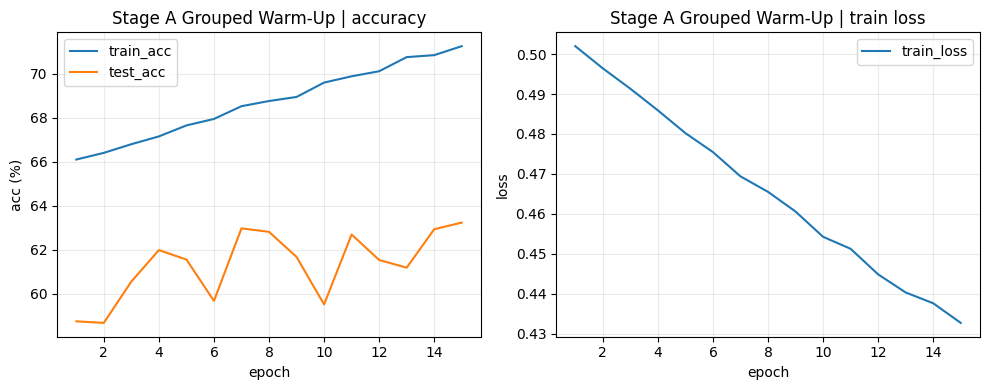

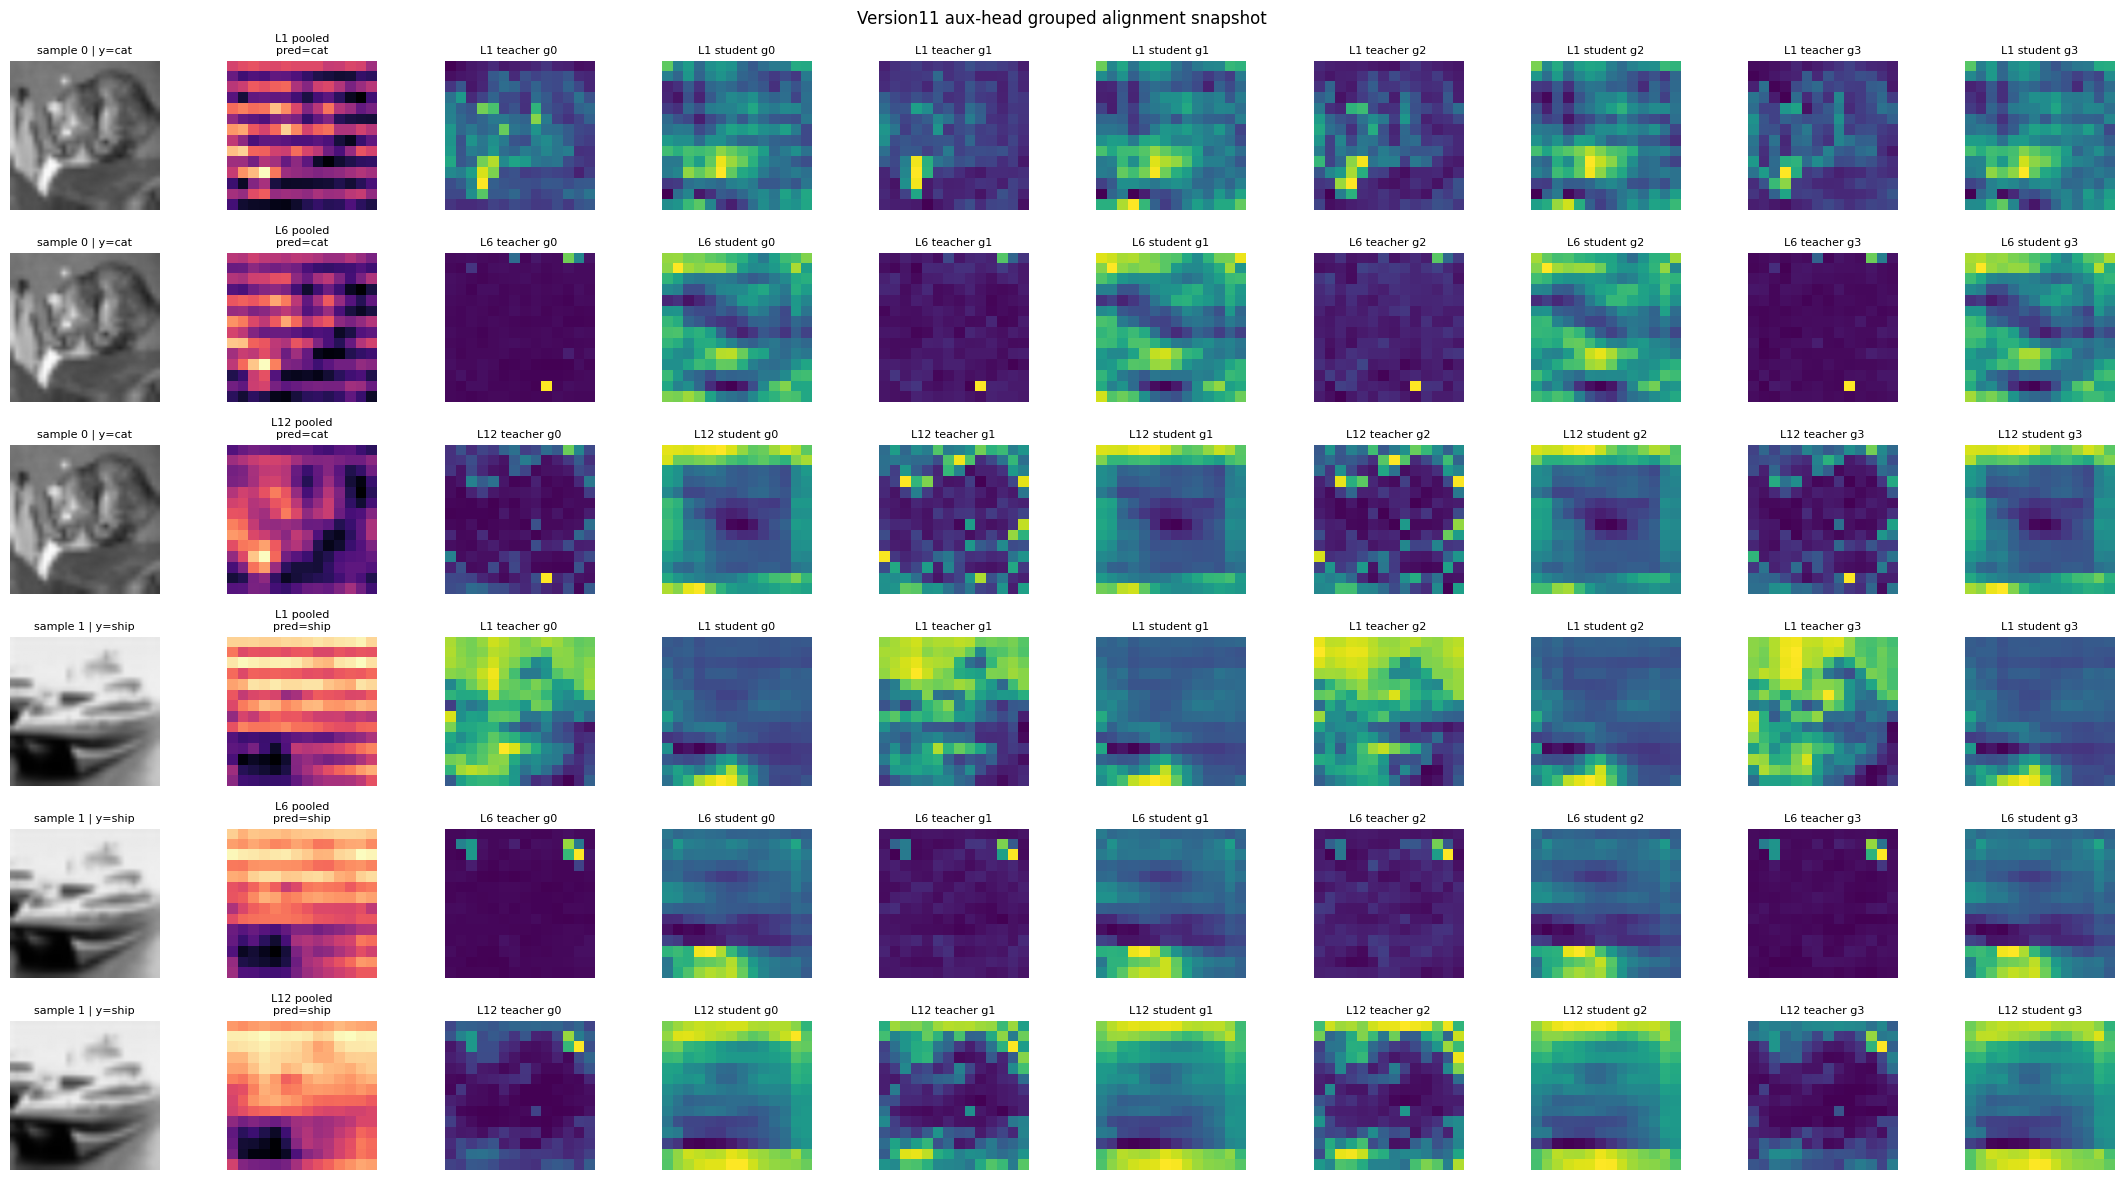

ok: 7A) Stage A 执行完成


In [28]:
if RUN_STAGE_A:
    if V11_INIT_MODE != "fresh" and not V11_ALLOW_STAGE_A_FROM_RESUME:
        print(f"Stage A 被跳过：当前 V11_INIT_MODE={V11_INIT_MODE}，且不允许从 resume 模式回头再热身。")
    else:
        selected_teacher_ckpt = None
        for candidate in STAGE_A_TEACHER_CKPT_CANDIDATES:
            if candidate.exists():
                selected_teacher_ckpt = candidate
                break
        if selected_teacher_ckpt is None:
            selected_teacher_ckpt = STAGE_A_TEACHER_CKPT_CANDIDATES[0]

        teacher_model_v11 = GrayViTTeacherV11(num_classes=NUM_CLASSES, pretrained=True, arch_name=V11_TEACHER_ARCH).to(DEVICE)
        teacher_model_v11, teacher_history_v11 = train_teacher_if_needed_v11(teacher=teacher_model_v11, train_loader=train_loader, test_loader=test_loader, device=DEVICE, ckpt_path=selected_teacher_ckpt, log_path=STAGE_A_TEACHER_LOG_PATH, epochs=2, lr=3e-5, weight_decay=1e-4, allow_train_if_missing=True)
        student_model_v11 = build_student_model_v11(cmos_electrical_mode=V11_CMOS_ELECTRICAL_MODE, cmos_reconstruction_phase_mode=V11_CMOS_RECON_PHASE_MODE, cmos_random_phase_scheme=V11_CMOS_RANDOM_PHASE_SCHEME, input_field_mode=V11_INPUT_FIELD_MODE, head_dropout=V11_HEAD_DROPOUT, group_count=V11_GROUP_COUNT, aux_head_positive_mode=V11_AUX_HEAD_POSITIVE_MODE, aux_head_hidden=V11_AUX_HEAD_HIDDEN, aux_head_use_batchnorm=V11_AUX_HEAD_USE_BATCHNORM)

        init_path = resolve_v11_init_path(V11_INIT_MODE, V11_INIT_CUSTOM_PATH)
        if init_path is not None and init_path.exists():
            _ = load_v11_bundle(student_model_v11, init_path, strict_head=False, load_backbone=True, load_head=True, load_projector=True)
            print(f"Stage A resumed from: {init_path}")
        else:
            print("Stage A starts from scratch.")

        stage_a_history_v11, stage_a_summary_v11 = run_joint_stage_v11(model=student_model_v11, teacher=teacher_model_v11, train_loader=train_loader, test_loader=test_loader, device=DEVICE, stage_name='StageA-GroupedWarmup', trainable_from_layer=STAGE_A_TRAINABLE_FROM_LAYER, epochs=STAGE_A_EPOCHS, lr=STAGE_A_LR, weight_decay=STAGE_A_WEIGHT_DECAY, teacher_map_mode=STAGE_A_TEACHER_MAP_MODE, map_loss_mode=STAGE_A_MAP_LOSS_MODE, fixed_map_layers=STAGE_A_FIXED_MAP_LAYERS, fixed_map_weight=STAGE_A_FIXED_MAP_WEIGHT, fixed_layer_weights=STAGE_A_FIXED_LAYER_WEIGHTS, grouped_layers=STAGE_A_GROUPED_LAYERS, grouped_weight=STAGE_A_GROUPED_WEIGHT, grouped_loss_mode=STAGE_A_GROUPED_LOSS_MODE, grouped_layer_weights=STAGE_A_GROUPED_LAYER_WEIGHTS, grouped_target_mode=STAGE_A_GROUP_TARGET_MODE, grouped_group_count=STAGE_A_GROUP_COUNT, grouped_grouping_mode=STAGE_A_GROUPING_MODE, use_logit_kd=STAGE_A_USE_LOGIT_KD, logit_kd_weight=STAGE_A_LOGIT_KD_WEIGHT, kd_tau=STAGE_A_KD_TAU, ce_weight=STAGE_A_CE_WEIGHT, chain_layers=STAGE_A_CHAIN_LAYERS, chain_weight=STAGE_A_CHAIN_WEIGHT, chain_map_mode=STAGE_A_CHAIN_MAP_MODE, chain_gate_power=STAGE_A_CHAIN_GATE_POWER, chain_gate_normalize=STAGE_A_CHAIN_GATE_NORMALIZE, save_path=STAGE_A_CKPT)
        save_json({'summary': asdict(stage_a_summary_v11), 'history': stage_a_history_v11}, STAGE_A_LOG)
        print(json.dumps(asdict(stage_a_summary_v11), indent=2, ensure_ascii=False))
        if AUTO_PLOT_HISTORY:
            plot_stage_history(stage_a_history_v11, title='Stage A Grouped Warm-Up', save_path=STAGE_A_FIG if AUTO_SAVE_PLOTS else None)
        if AUTO_VISUALIZE_TARGETS:
            visualize_grouped_targets_and_predictions(model=student_model_v11, teacher=teacher_model_v11, loader=test_loader, device=DEVICE, layers=VIS_LAYERS, groups=VIS_GROUPS, num_samples=VIS_NUM_SAMPLES, teacher_map_mode=STAGE_A_TEACHER_MAP_MODE, grouping_mode=STAGE_A_GROUPING_MODE, grouped_mode=STAGE_A_GROUP_TARGET_MODE, save_path=STAGE_A_ALIGN_FIG if AUTO_SAVE_PLOTS else None)
else:
    print('Stage A is skipped by config.')

print('ok: 7A) Stage A 执行完成')


## 8) Stage B：Aux-head grouped target 主训练阶段

Version11 的主要增益希望出现在这里。

这阶段的直觉是：

- backbone 从 V8/V10 的已有表征出发
- aux head 负责把 grouped target 真正“接住”
- grouped KD 成为主监督
- fixed map KD 继续做锚点
- logit KD / CE 保证分类目标不丢
- chain 暂时很弱，避免它再次抢走主要解释权


In [33]:
RUN_STAGE_B = True
STAGE_B_TRAINABLE_FROM_LAYER = 10
STAGE_B_EPOCHS = 100
STAGE_B_LR = 1e-4
STAGE_B_WEIGHT_DECAY = 1e-4
STAGE_B_TEACHER_MAP_MODE = "patch_rms"
STAGE_B_MAP_LOSS_MODE = "log_huber"
STAGE_B_FIXED_MAP_LAYERS = (9, 10, 11, 12)
STAGE_B_FIXED_MAP_WEIGHT = 0.15
STAGE_B_FIXED_LAYER_WEIGHTS = {9: 0.8, 10: 1.0, 11: 1.5, 12: 2.0}
STAGE_B_GROUPED_LAYERS = (8, 9, 10, 11, 12)
STAGE_B_GROUPED_WEIGHT = 0.85
STAGE_B_GROUPED_LOSS_MODE = "log_huber"
STAGE_B_GROUPED_LAYER_WEIGHTS = {8: 0.8, 9: 1.0, 10: 1.2, 11: 1.5, 12: 1.8}
STAGE_B_GROUP_TARGET_MODE = V11_GROUP_TARGET_MODE
STAGE_B_GROUP_COUNT = V11_GROUP_COUNT
STAGE_B_GROUPING_MODE = V11_GROUPING_MODE
STAGE_B_CHAIN_LAYERS = ()
STAGE_B_CHAIN_WEIGHT = 0.00
STAGE_B_CHAIN_MAP_MODE = "patch_rms"
STAGE_B_CHAIN_GATE_POWER = 1.0
STAGE_B_CHAIN_GATE_NORMALIZE = "mean"
STAGE_B_USE_LOGIT_KD = True
STAGE_B_LOGIT_KD_WEIGHT = 0.25
STAGE_B_KD_TAU = 2.0
STAGE_B_CE_WEIGHT = 0.12
STAGE_B_CKPT = CKPT_DIR / "version11_stage_b_auxhead_best.pth"
STAGE_B_LOG = LOG_DIR / "version11_stage_b_auxhead_history.json"
STAGE_B_FIG = FIG_DIR / "version11_stage_b_history.png"
STAGE_B_ALIGN_FIG = FIG_DIR / "version11_stage_b_alignment.png"
print("ok: 8) Stage B 配置")


ok: 8) Stage B 配置


StageB-GroupedMain | trainable_from_layer = 10
trainable params = 207710
group_count = 4 | grouping_mode = interleave | grouped_target_mode = group_rms


StageB-GroupedMain 1/100: 100%|██████████| 782/782 [02:15<00:00,  5.78it/s, acc=78.62%, chain=0.0000, fixed=0.1287, grouped=0.0378, total=0.5569]
                                                                                

StageB-GroupedMain epoch 01/100 | train_acc=78.62% | test_acc=66.55% | epoch_time=02m 24s


StageB-GroupedMain 2/100: 100%|██████████| 782/782 [02:17<00:00,  5.70it/s, acc=78.90%, chain=0.0000, fixed=0.1287, grouped=0.0377, total=0.5528]
                                                                                

StageB-GroupedMain epoch 02/100 | train_acc=78.90% | test_acc=66.99% | epoch_time=02m 27s


...

StageB-GroupedMain epoch 98/100 | train_acc=85.49% | test_acc=66.35% | epoch_time=02m 26s


StageB-GroupedMain 99/100: 100%|██████████| 782/782 [02:16<00:00,  5.73it/s, acc=85.54%, chain=0.0000, fixed=0.1285, grouped=0.0370, total=0.4314]
                                                                                 

StageB-GroupedMain epoch 99/100 | train_acc=85.54% | test_acc=65.68% | epoch_time=02m 25s


StageB-GroupedMain 100/100: 100%|██████████| 782/782 [02:16<00:00,  5.74it/s, acc=85.48%, chain=0.0000, fixed=0.1285, grouped=0.0370, total=0.4344]
                                                                                  

StageB-GroupedMain epoch 100/100 | train_acc=85.48% | test_acc=66.35% | epoch_time=02m 26s
StageB-GroupedMain finished in 4h 05m 32s
{
  "stage_name": "StageB-GroupedMain",
  "total_epochs": 100,
  "trainable_from_layer": 10,
  "best_test_acc": 0.6727,
  "best_epoch": 25,
  "last_train_loss": 0.43437942651748657,
  "last_train_acc": 0.85482,
  "last_test_acc": 0.6635,
  "save_path": "results_task3_kd_v11_auxhead/checkpoints/version11_stage_b_auxhead_best.pth"
}


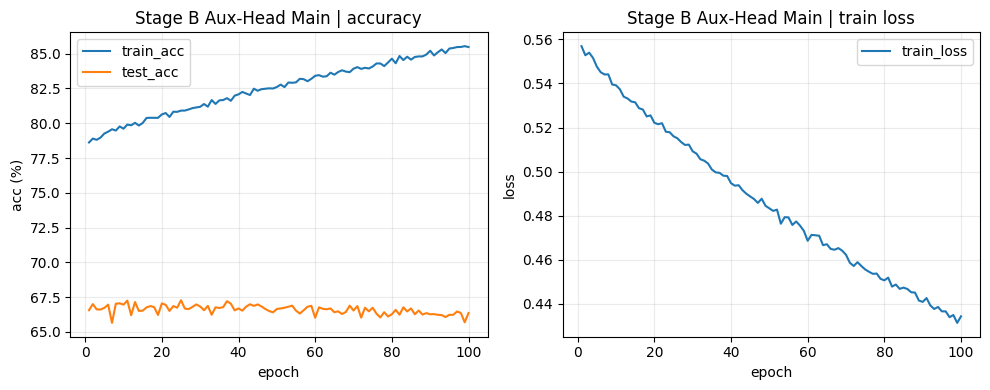

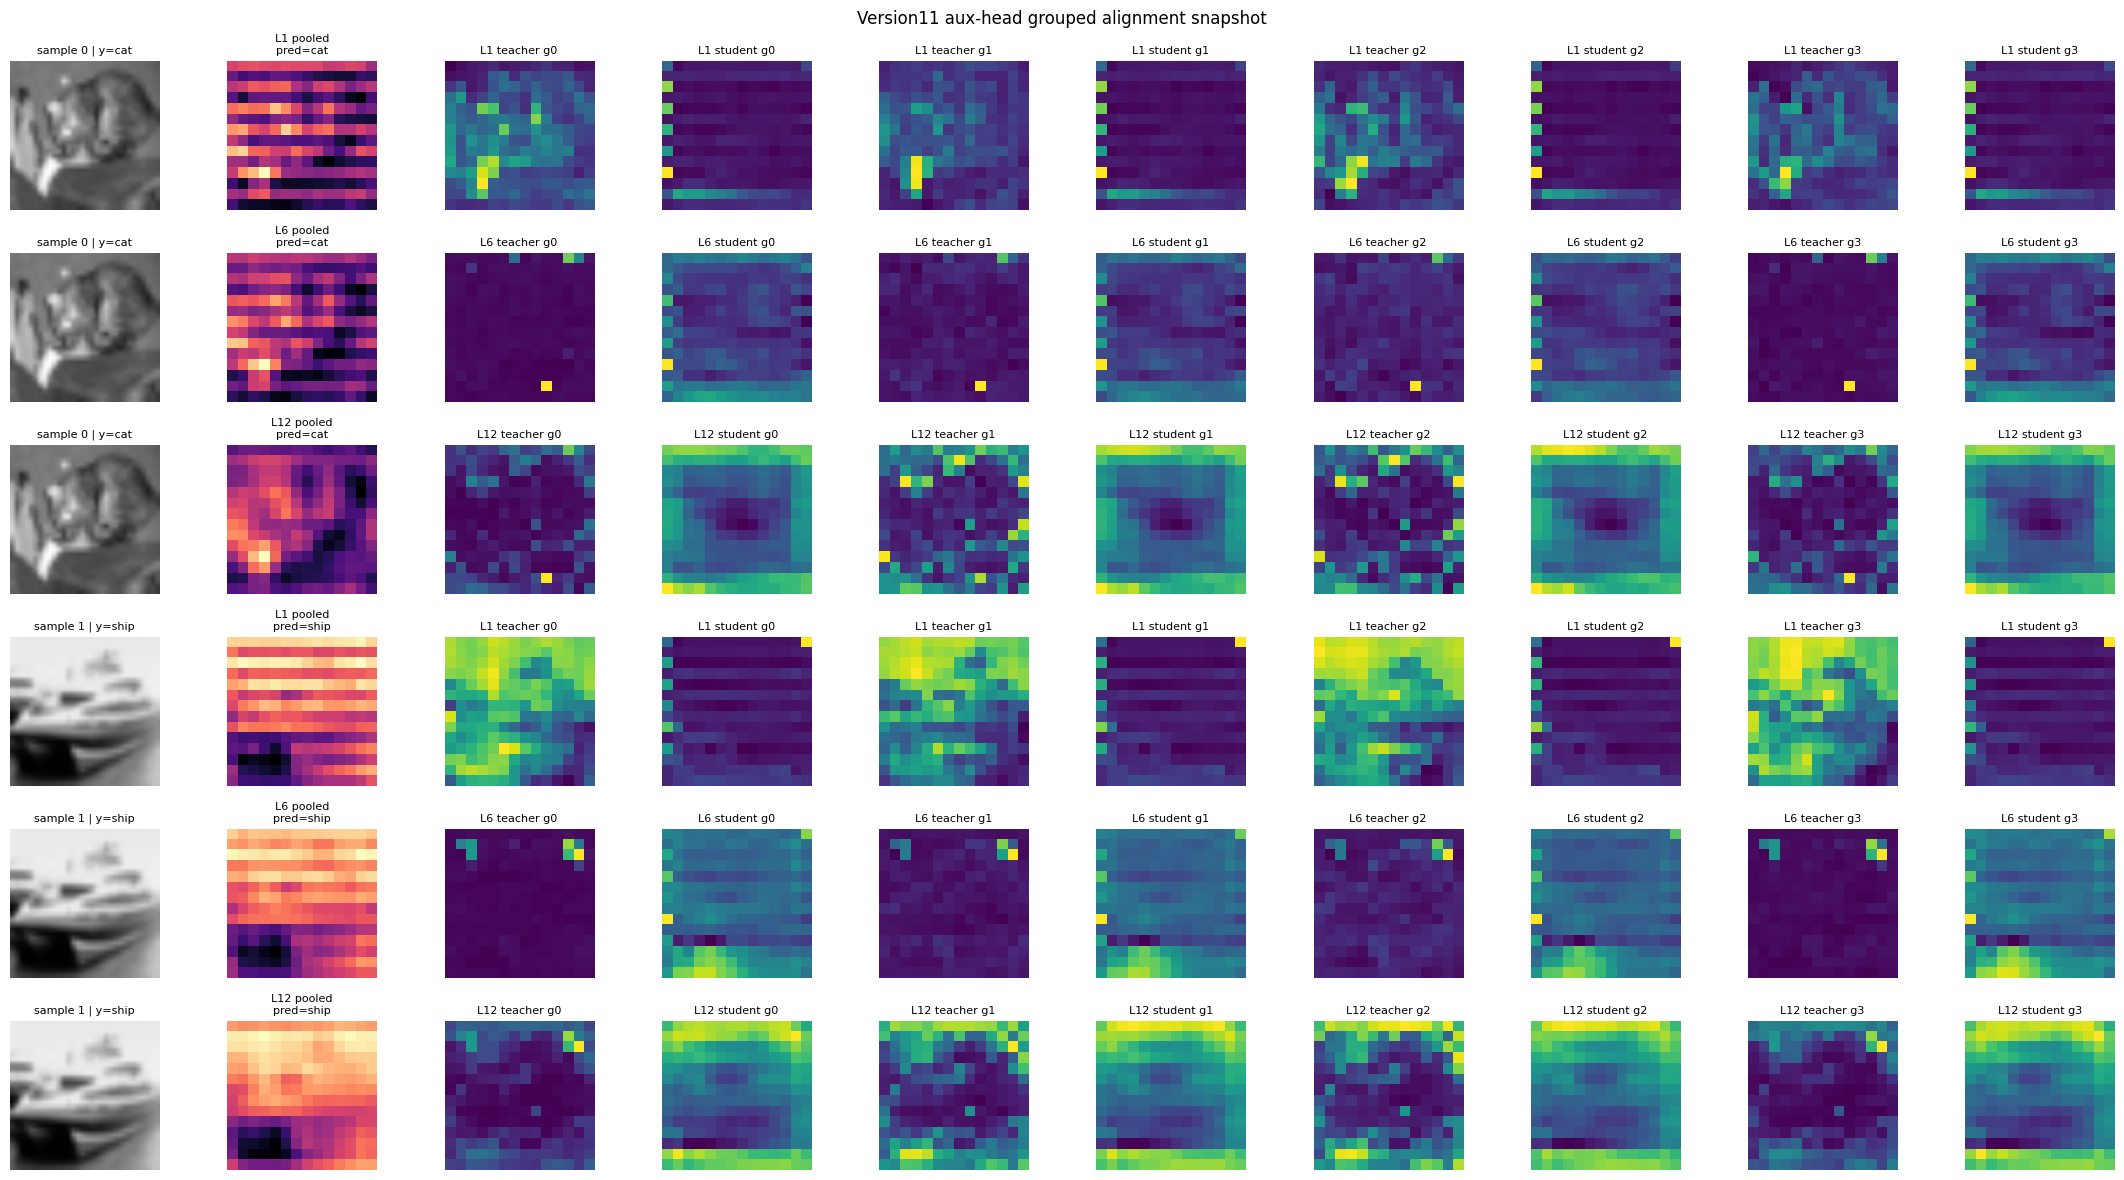

ok: 8B) Stage B 执行完成


In [34]:
if RUN_STAGE_B:
    if "teacher_model_v11" not in globals():
        selected_teacher_ckpt = None
        for candidate in STAGE_A_TEACHER_CKPT_CANDIDATES:
            if candidate.exists():
                selected_teacher_ckpt = candidate
                break
        if selected_teacher_ckpt is None:
            selected_teacher_ckpt = STAGE_A_TEACHER_CKPT_CANDIDATES[0]
        teacher_model_v11 = GrayViTTeacherV11(num_classes=NUM_CLASSES, pretrained=True, arch_name=V11_TEACHER_ARCH).to(DEVICE)
        teacher_model_v11, teacher_history_v11 = train_teacher_if_needed_v11(teacher=teacher_model_v11, train_loader=train_loader, test_loader=test_loader, device=DEVICE, ckpt_path=selected_teacher_ckpt, log_path=STAGE_A_TEACHER_LOG_PATH, epochs=2, lr=3e-5, weight_decay=1e-4, allow_train_if_missing=True)

    if "student_model_v11" not in globals():
        student_model_v11 = build_student_model_v11(cmos_electrical_mode=V11_CMOS_ELECTRICAL_MODE, cmos_reconstruction_phase_mode=V11_CMOS_RECON_PHASE_MODE, cmos_random_phase_scheme=V11_CMOS_RANDOM_PHASE_SCHEME, input_field_mode=V11_INPUT_FIELD_MODE, head_dropout=V11_HEAD_DROPOUT, group_count=V11_GROUP_COUNT, aux_head_positive_mode=V11_AUX_HEAD_POSITIVE_MODE, aux_head_hidden=V11_AUX_HEAD_HIDDEN, aux_head_use_batchnorm=V11_AUX_HEAD_USE_BATCHNORM)
        init_path = resolve_v11_init_path(V11_INIT_MODE, V11_INIT_CUSTOM_PATH)
        if init_path is not None and init_path.exists():
            _ = load_v11_bundle(student_model_v11, init_path, strict_head=False, load_backbone=True, load_head=True, load_projector=True)
            print(f"Stage B resumed from: {init_path}")
        elif STAGE_A_CKPT.exists():
            _ = load_v11_bundle(student_model_v11, STAGE_A_CKPT, strict_head=False, load_backbone=True, load_head=True, load_projector=True)

    stage_b_history_v11, stage_b_summary_v11 = run_joint_stage_v11(model=student_model_v11, teacher=teacher_model_v11, train_loader=train_loader, test_loader=test_loader, device=DEVICE, stage_name="StageB-GroupedMain", trainable_from_layer=STAGE_B_TRAINABLE_FROM_LAYER, epochs=STAGE_B_EPOCHS, lr=STAGE_B_LR, weight_decay=STAGE_B_WEIGHT_DECAY, teacher_map_mode=STAGE_B_TEACHER_MAP_MODE, map_loss_mode=STAGE_B_MAP_LOSS_MODE, fixed_map_layers=STAGE_B_FIXED_MAP_LAYERS, fixed_map_weight=STAGE_B_FIXED_MAP_WEIGHT, fixed_layer_weights=STAGE_B_FIXED_LAYER_WEIGHTS, grouped_layers=STAGE_B_GROUPED_LAYERS, grouped_weight=STAGE_B_GROUPED_WEIGHT, grouped_loss_mode=STAGE_B_GROUPED_LOSS_MODE, grouped_layer_weights=STAGE_B_GROUPED_LAYER_WEIGHTS, grouped_target_mode=STAGE_B_GROUP_TARGET_MODE, grouped_group_count=STAGE_B_GROUP_COUNT, grouped_grouping_mode=STAGE_B_GROUPING_MODE, use_logit_kd=STAGE_B_USE_LOGIT_KD, logit_kd_weight=STAGE_B_LOGIT_KD_WEIGHT, kd_tau=STAGE_B_KD_TAU, ce_weight=STAGE_B_CE_WEIGHT, chain_layers=STAGE_B_CHAIN_LAYERS, chain_weight=STAGE_B_CHAIN_WEIGHT, chain_map_mode=STAGE_B_CHAIN_MAP_MODE, chain_gate_power=STAGE_B_CHAIN_GATE_POWER, chain_gate_normalize=STAGE_B_CHAIN_GATE_NORMALIZE, save_path=STAGE_B_CKPT)
    save_json({"summary": asdict(stage_b_summary_v11), "history": stage_b_history_v11}, STAGE_B_LOG)
    print(json.dumps(asdict(stage_b_summary_v11), indent=2, ensure_ascii=False))
    if AUTO_PLOT_HISTORY:
        plot_stage_history(stage_b_history_v11, title='Stage B Aux-Head Main', save_path=STAGE_B_FIG if AUTO_SAVE_PLOTS else None)
    if AUTO_VISUALIZE_TARGETS:
        visualize_grouped_targets_and_predictions(model=student_model_v11, teacher=teacher_model_v11, loader=test_loader, device=DEVICE, layers=VIS_LAYERS, groups=VIS_GROUPS, num_samples=VIS_NUM_SAMPLES, teacher_map_mode=STAGE_B_TEACHER_MAP_MODE, grouping_mode=STAGE_B_GROUPING_MODE, grouped_mode=STAGE_B_GROUP_TARGET_MODE, save_path=STAGE_B_ALIGN_FIG if AUTO_SAVE_PLOTS else None)
else:
    print("Stage B is skipped by config.")

print("ok: 8B) Stage B 执行完成")


## 9) Stage C：低学习率稳定微调

Stage C 的职责不是重新造新东西，而是：

- 在 Stage B 已经出现正 signal 的前提下
- 放开略早一点的后层
- 让 backbone 与 aux head / grouped target 的新配合再稳定一些

如果 Stage B 没有任何提升，建议先别急着长训 Stage C。


In [25]:
RUN_STAGE_C = True
STAGE_C_TRAINABLE_FROM_LAYER = 8
STAGE_C_EPOCHS = 3
STAGE_C_LR = 5e-5
STAGE_C_WEIGHT_DECAY = 1e-4
STAGE_C_TEACHER_MAP_MODE = "patch_rms"
STAGE_C_MAP_LOSS_MODE = "log_huber"
STAGE_C_FIXED_MAP_LAYERS = (9, 10, 11, 12)
STAGE_C_FIXED_MAP_WEIGHT = 0.10
STAGE_C_FIXED_LAYER_WEIGHTS = {9: 0.8, 10: 1.0, 11: 1.5, 12: 2.0}
STAGE_C_GROUPED_LAYERS = (8, 9, 10, 11, 12)
STAGE_C_GROUPED_WEIGHT = 0.55
STAGE_C_GROUPED_LOSS_MODE = "log_huber"
STAGE_C_GROUPED_LAYER_WEIGHTS = {8: 0.8, 9: 1.0, 10: 1.2, 11: 1.5, 12: 1.8}
STAGE_C_GROUP_TARGET_MODE = V11_GROUP_TARGET_MODE
STAGE_C_GROUP_COUNT = V11_GROUP_COUNT
STAGE_C_GROUPING_MODE = V11_GROUPING_MODE
STAGE_C_CHAIN_LAYERS = (10, 11, 12)
STAGE_C_CHAIN_WEIGHT = 0.03
STAGE_C_CHAIN_MAP_MODE = "patch_rms"
STAGE_C_CHAIN_GATE_POWER = 1.0
STAGE_C_CHAIN_GATE_NORMALIZE = "mean"
STAGE_C_USE_LOGIT_KD = True
STAGE_C_LOGIT_KD_WEIGHT = 0.20
STAGE_C_KD_TAU = 2.0
STAGE_C_CE_WEIGHT = 0.15
STAGE_C_CKPT = CKPT_DIR / "version11_stage_c_auxhead_best.pth"
STAGE_C_LOG = LOG_DIR / "version11_stage_c_auxhead_history.json"
STAGE_C_FIG = FIG_DIR / "version11_stage_c_history.png"
STAGE_C_ALIGN_FIG = FIG_DIR / "version11_stage_c_alignment.png"
print("ok: 9) Stage C 配置")


ok: 9) Stage C 配置


StageC-GroupedStable | trainable_from_layer = 8
trainable params = 240478
group_count = 4 | grouping_mode = interleave | grouped_target_mode = group_rms


StageC-GroupedStable 1/3: 100%|██████████| 782/782 [02:16<00:00,  5.72it/s, acc=70.44%, chain=0.1055, fixed=0.1298, grouped=0.0403, total=0.6305]
                                                                                

StageC-GroupedStable epoch 01/03 | train_acc=70.44% | test_acc=64.83% | epoch_time=02m 26s


StageC-GroupedStable 2/3: 100%|██████████| 782/782 [02:17<00:00,  5.67it/s, acc=70.31%, chain=0.1055, fixed=0.1298, grouped=0.0403, total=0.6302]
                                                                                

StageC-GroupedStable epoch 02/03 | train_acc=70.31% | test_acc=65.17% | epoch_time=02m 27s


StageC-GroupedStable 3/3: 100%|██████████| 782/782 [02:18<00:00,  5.63it/s, acc=70.67%, chain=0.1055, fixed=0.1298, grouped=0.0402, total=0.6266]
                                                                                

StageC-GroupedStable epoch 03/03 | train_acc=70.67% | test_acc=65.14% | epoch_time=02m 28s
StageC-GroupedStable finished in 07m 21s
{
  "stage_name": "StageC-GroupedStable",
  "total_epochs": 3,
  "trainable_from_layer": 8,
  "best_test_acc": 0.6517,
  "best_epoch": 2,
  "last_train_loss": 0.6266024738502503,
  "last_train_acc": 0.70674,
  "last_test_acc": 0.6514,
  "save_path": "results_task3_kd_v11_auxhead/checkpoints/version11_stage_c_auxhead_best.pth"
}


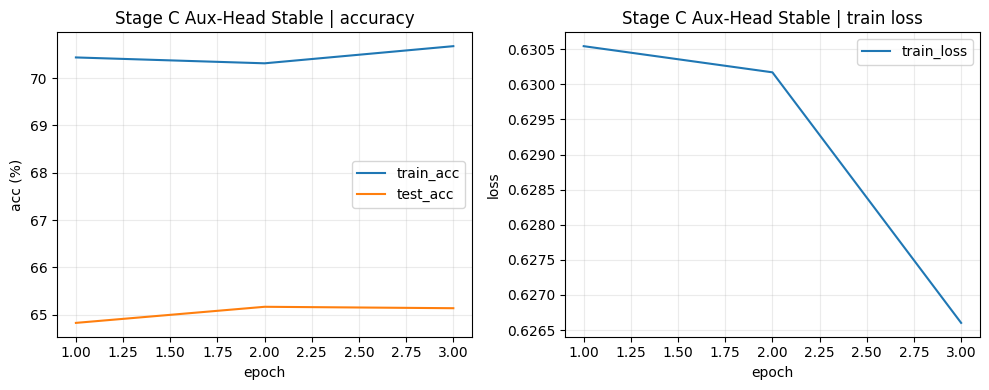

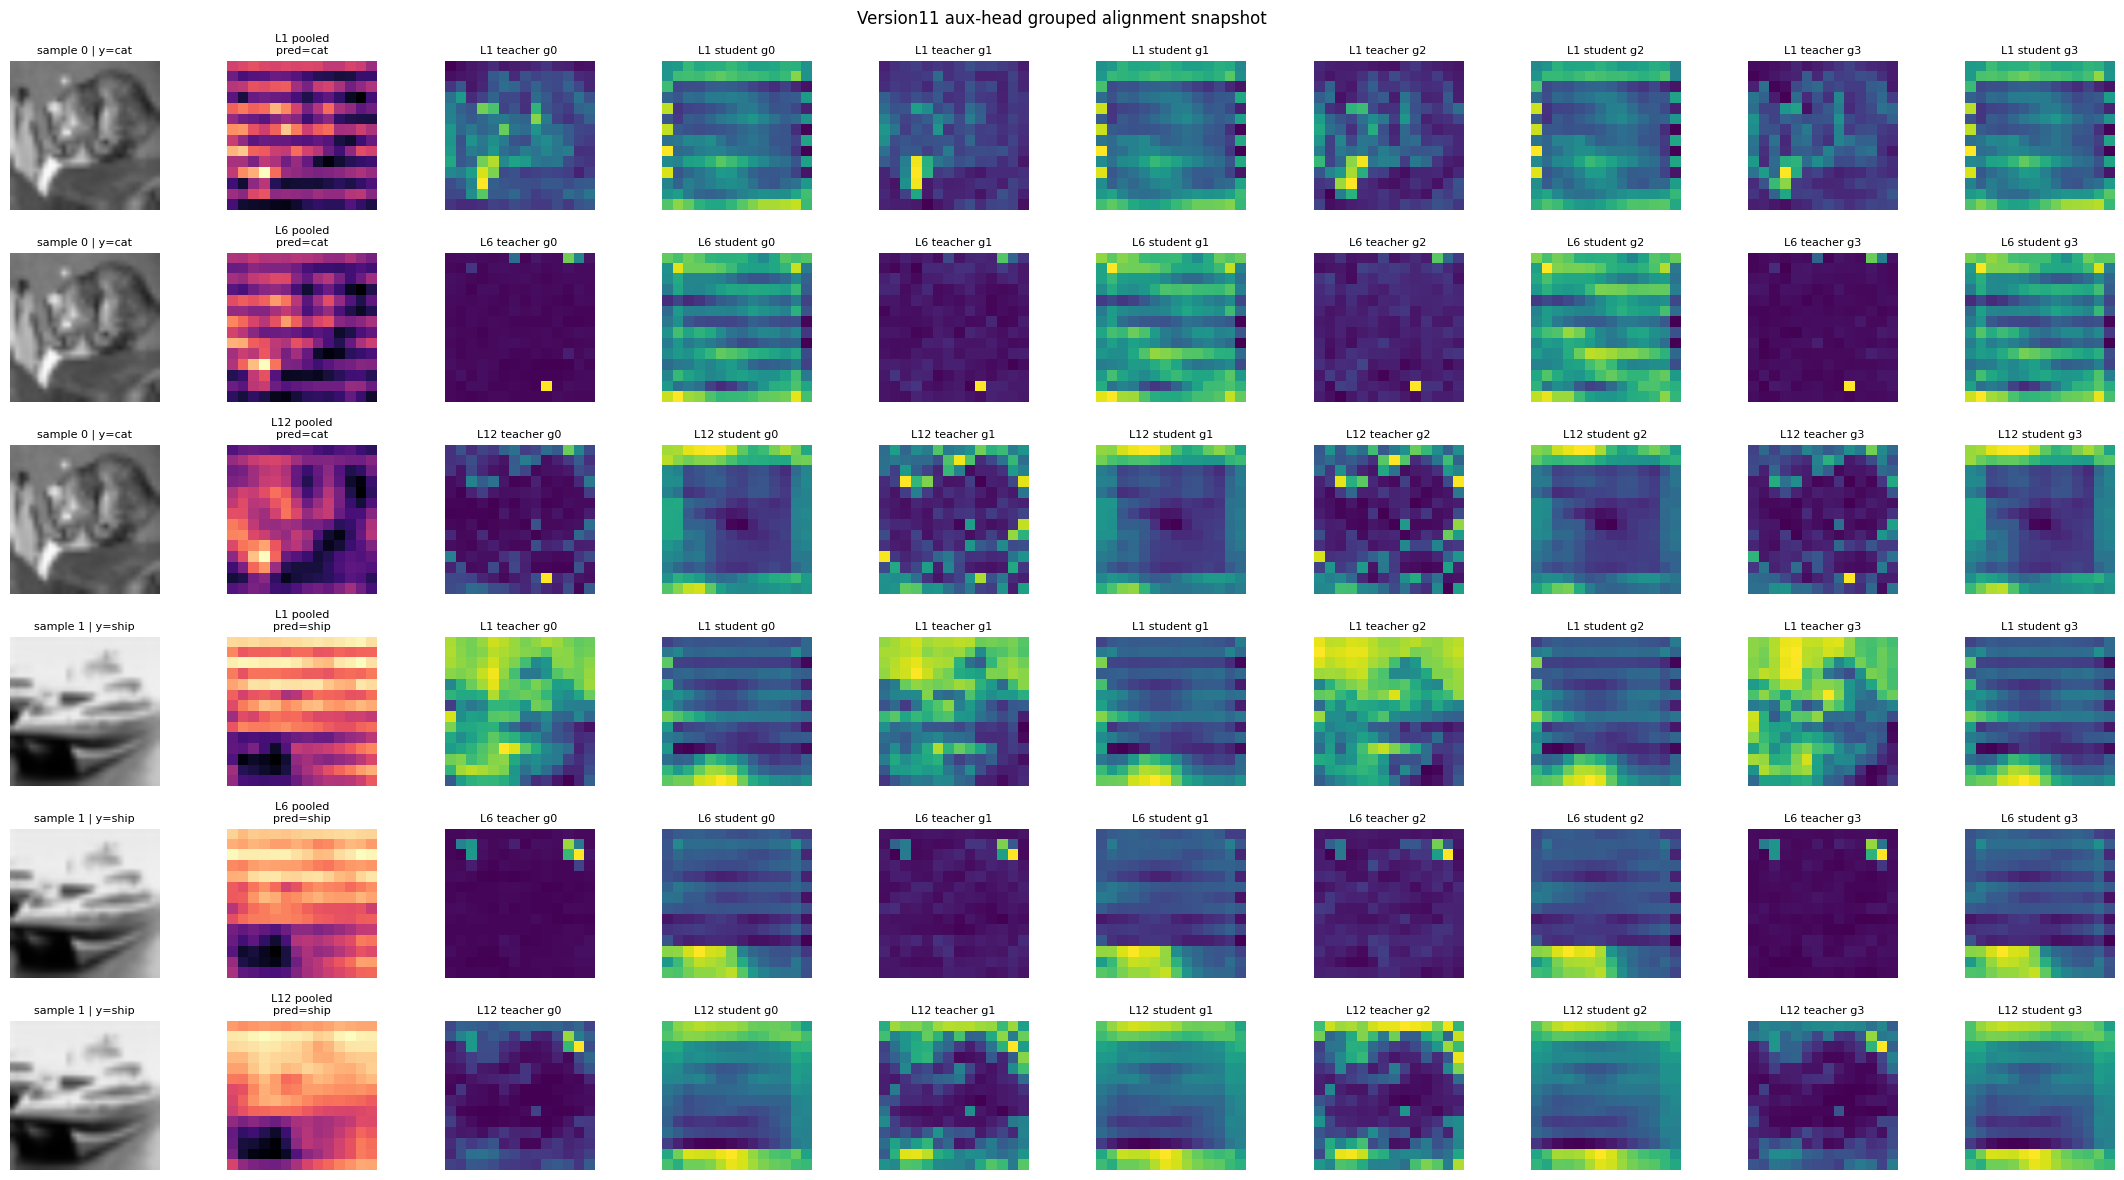

ok: 9C) Stage C 执行完成


In [26]:
if RUN_STAGE_C:
    if "teacher_model_v11" not in globals():
        selected_teacher_ckpt = None
        for candidate in STAGE_A_TEACHER_CKPT_CANDIDATES:
            if candidate.exists():
                selected_teacher_ckpt = candidate
                break
        if selected_teacher_ckpt is None:
            selected_teacher_ckpt = STAGE_A_TEACHER_CKPT_CANDIDATES[0]
        teacher_model_v11 = GrayViTTeacherV11(num_classes=NUM_CLASSES, pretrained=True, arch_name=V11_TEACHER_ARCH).to(DEVICE)
        teacher_model_v11, teacher_history_v11 = train_teacher_if_needed_v11(teacher=teacher_model_v11, train_loader=train_loader, test_loader=test_loader, device=DEVICE, ckpt_path=selected_teacher_ckpt, log_path=STAGE_A_TEACHER_LOG_PATH, epochs=2, lr=3e-5, weight_decay=1e-4, allow_train_if_missing=True)

    if "student_model_v11" not in globals():
        student_model_v11 = build_student_model_v11(cmos_electrical_mode=V11_CMOS_ELECTRICAL_MODE, cmos_reconstruction_phase_mode=V11_CMOS_RECON_PHASE_MODE, cmos_random_phase_scheme=V11_CMOS_RANDOM_PHASE_SCHEME, input_field_mode=V11_INPUT_FIELD_MODE, head_dropout=V11_HEAD_DROPOUT, group_count=V11_GROUP_COUNT, aux_head_positive_mode=V11_AUX_HEAD_POSITIVE_MODE, aux_head_hidden=V11_AUX_HEAD_HIDDEN, aux_head_use_batchnorm=V11_AUX_HEAD_USE_BATCHNORM)

    if STAGE_B_CKPT.exists():
        _ = load_v11_bundle(student_model_v11, STAGE_B_CKPT, strict_head=False, load_backbone=True, load_head=True, load_projector=True)
    else:
        init_path = resolve_v11_init_path(V11_INIT_MODE, V11_INIT_CUSTOM_PATH)
        if init_path is not None and init_path.exists():
            _ = load_v11_bundle(student_model_v11, init_path, strict_head=False, load_backbone=True, load_head=True, load_projector=True)
            print(f"Stage C resumed from: {init_path}")

    stage_c_history_v11, stage_c_summary_v11 = run_joint_stage_v11(model=student_model_v11, teacher=teacher_model_v11, train_loader=train_loader, test_loader=test_loader, device=DEVICE, stage_name="StageC-GroupedStable", trainable_from_layer=STAGE_C_TRAINABLE_FROM_LAYER, epochs=STAGE_C_EPOCHS, lr=STAGE_C_LR, weight_decay=STAGE_C_WEIGHT_DECAY, teacher_map_mode=STAGE_C_TEACHER_MAP_MODE, map_loss_mode=STAGE_C_MAP_LOSS_MODE, fixed_map_layers=STAGE_C_FIXED_MAP_LAYERS, fixed_map_weight=STAGE_C_FIXED_MAP_WEIGHT, fixed_layer_weights=STAGE_C_FIXED_LAYER_WEIGHTS, grouped_layers=STAGE_C_GROUPED_LAYERS, grouped_weight=STAGE_C_GROUPED_WEIGHT, grouped_loss_mode=STAGE_C_GROUPED_LOSS_MODE, grouped_layer_weights=STAGE_C_GROUPED_LAYER_WEIGHTS, grouped_target_mode=STAGE_C_GROUP_TARGET_MODE, grouped_group_count=STAGE_C_GROUP_COUNT, grouped_grouping_mode=STAGE_C_GROUPING_MODE, use_logit_kd=STAGE_C_USE_LOGIT_KD, logit_kd_weight=STAGE_C_LOGIT_KD_WEIGHT, kd_tau=STAGE_C_KD_TAU, ce_weight=STAGE_C_CE_WEIGHT, chain_layers=STAGE_C_CHAIN_LAYERS, chain_weight=STAGE_C_CHAIN_WEIGHT, chain_map_mode=STAGE_C_CHAIN_MAP_MODE, chain_gate_power=STAGE_C_CHAIN_GATE_POWER, chain_gate_normalize=STAGE_C_CHAIN_GATE_NORMALIZE, save_path=STAGE_C_CKPT)
    save_json({"summary": asdict(stage_c_summary_v11), "history": stage_c_history_v11}, STAGE_C_LOG)
    print(json.dumps(asdict(stage_c_summary_v11), indent=2, ensure_ascii=False))
    if AUTO_PLOT_HISTORY:
        plot_stage_history(stage_c_history_v11, title='Stage C Aux-Head Stable', save_path=STAGE_C_FIG if AUTO_SAVE_PLOTS else None)
    if AUTO_VISUALIZE_TARGETS:
        visualize_grouped_targets_and_predictions(model=student_model_v11, teacher=teacher_model_v11, loader=test_loader, device=DEVICE, layers=VIS_LAYERS, groups=VIS_GROUPS, num_samples=VIS_NUM_SAMPLES, teacher_map_mode=STAGE_C_TEACHER_MAP_MODE, grouping_mode=STAGE_C_GROUPING_MODE, grouped_mode=STAGE_C_GROUP_TARGET_MODE, save_path=STAGE_C_ALIGN_FIG if AUTO_SAVE_PLOTS else None)
else:
    print("Stage C is skipped by config.")

print("ok: 9C) Stage C 执行完成")


## 10) 风险、推荐操作与后续可改点

### 当前 Version11 的设计边界
- 学生主推理路径不改
- 测试/部署阶段不用 auxiliary grouped head
- auxiliary grouped head 只在训练/蒸馏阶段存在
- 这版主要回答的问题是：`student-side distillation interface 太弱` 是否是 Version10 ceiling 的关键来源

### 推荐第一轮操作
1. 保持 `V11_INIT_MODE = "resume_v8c"`
2. 保持 `RUN_STAGE_A = False`
3. 先跑 `Stage B`
4. 如果 `Stage B` 有正 signal，再跑 `Stage C`
5. 如果只是做快速诊断，不建议一开始把 `Stage C` 拉得很长

### 当前主要风险
1. auxiliary grouped head 过强时，可能先学会“自己拟合 grouped target”，而 backbone 改得不够
2. `K` 太大仍可能让 grouped target 变噪，第一轮仍建议保持 4
3. 如果从 V8 checkpoint 读取，aux head 没有旧权重，随机初始化属于正常现象
4. chain 在这版仍然不是主角，如果重新开得太重，容易再次遮住 grouped interface 的真实作用

### 这版最值得优先改的参数
1. `V11_AUX_HEAD_HIDDEN`
2. `V11_AUX_HEAD_USE_BATCHNORM`
3. `V11_GROUP_COUNT`
4. `STAGE_B_GROUPED_WEIGHT`
5. `STAGE_C_GROUPED_WEIGHT`
6. `STAGE_B_TRAINABLE_FROM_LAYER / STAGE_C_TRAINABLE_FROM_LAYER`

### 一句提醒
如果这版仍然明显卡住，结论就会更清楚：
- 不是 teacher target 太单薄
- 也不是 distillation interface 太弱
- 而更可能是学生主干自身的观测/表达接口开始成为下一层瓶颈
